### ☀️ 참고 ☀️ 한글깨짐 방지

- 아래 코드셀 3개 실행 필수
- 윈도우, 맥 동일

❗️주의❗️
- Step1. 첫째 셀 실행
- Step2. '런타임 > 세션 다시시작'
- Step3. 이후 두번째 셀 실행

In [313]:
# 나눔 폰트 설치
# 해당 셀 실행 후 '런타임 > 세션 다시 시작'

# %%capture

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [314]:
import matplotlib.pyplot as plt
import matplotlib as mpl


# 나눔고딕 폰트 사용 설정 (폰트 설치 후 실행)
plt.rcParams["font.family"]="NanumGothic"

# 마이너스 깨짐 방지 (일반 하이픈(-)을 사용하게 설정)
mpl.rcParams['axes.unicode_minus'] = False

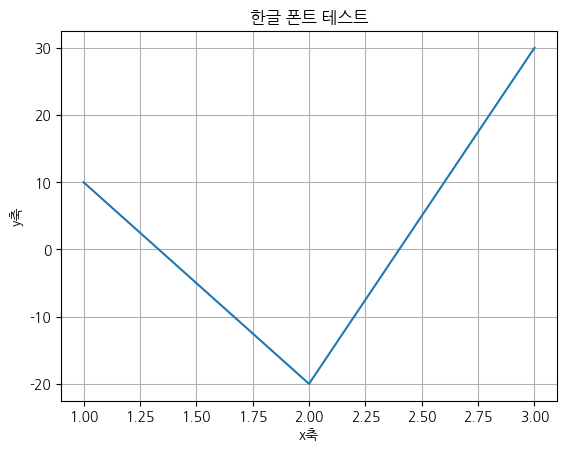

In [315]:
# 한글 폰트 테스트 그래프

plt.plot([1, 2, 3], [10, -20, 30])
plt.title('한글 폰트 테스트')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid(True)
plt.show()

# 📘 CH12. 회귀와 분류 모델 — 강의용 노트북

> 🔄 **개정 안내**: 이번 개정판부터는 하루 전체가 하나의 스토리로 이어집니다.
> - 오전(회귀): 공유 모빌리티 기업 **OO모빌리티**의 데이터 분석가가 되어 자전거 수요를 예측합니다.
> - 오후(분류): 대기업 **OO전자**의 인사(HR)팀으로 파견되어 퇴사 위험 직원을 찾아냅니다.
> - 마무리(보너스): 프롭테크 분석가가 되어 **내 조건의 아파트 가격**을 직접 예측해봅니다.
> - TODO 실습과 실습 과제는 정규 수업이 아닌 **수업 후 자습 시간(3시간)** 에 진행합니다. 정규 수업에서는 개념 설명 · 실무 시연 · Check Point 위주로 진행해주세요.
> - 🖥️ 라이브 데모와 🎁 보너스 소단원은 진도 상황에 따라 건너뛸 수 있는 독립 구성이며, 정규 4시간 개념 진도에 포함되지 않습니다.

# 📘 CH12-01. 회귀 모델

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 오늘의 미션 소개 → 데이터 준비(공유 자전거 수요) → Linear Regression → Decision Tree Regressor → Random Forest Regressor → Gradient Boosting Regressor → XGBRegressor → 선형모델 vs 트리모델 비교
> 🔧 **실습파일**: 필요 (`bike_sharing_hourly.csv` — 사전 배포)
> ⏱️ **예상 소요시간**: 60분 이상
> 🎚️ **난이도**: ★★★★★
> 🔗 **사전 지식**: CH03-01 전체, CH10(인코딩), CH09(자료형 변환)

---

## 🤔 먼저 생각해보기

> **여러분은 공유 자전거 서비스를 운영하는 OO모빌리티의 데이터 분석가입니다. 운영팀에서 이런 요청이 왔습니다 — "내일 시간대별로 자전거가 몇 대나 필요할지 미리 알려주세요. 너무 적게 배치하면 자전거가 없어서 고객이 이탈하고, 너무 많이 배치하면 놀고 있는 자전거 때문에 운영비만 나갑니다." 여러분이라면 무엇을 근거로 이 숫자를 예측하시겠습니까?**

날씨, 시간대, 요일, 공휴일 여부 같은 정보들이 실제로 수요와 관련이 있을 것 같다는 감이 오실 겁니다. 이번 챕터에서는 실제 공유 자전거 운영 데이터로 대표적인 회귀 모델 5가지를 직접 학습시켜보며, 이 예측을 어떤 방식으로 풀어낼 수 있는지 체감해봅니다.

> 💡 이번 챕터는 scikit-learn 공식 예제에도 등장하는 실제 공유 자전거 운영 데이터(Bike Sharing Demand, 2011~2012년 워싱턴 D.C., 17,379시간 분량)를 사용합니다. California Housing 못지않게 특성이 풍부하고 실무에서 자주 다뤄지는 "수요 예측" 문제의 정석 데이터셋입니다.

### 0) 데이터 준비 — 공유 자전거 시간대별 대여량

- `season`(계절), `weather`(날씨), `temp`(기온), `humidity`(습도), `windspeed`(풍속), `hour`(시간), `weekday`(요일), `holiday`/`workingday`(공휴일·평일 여부) 등 12개 특성
- 목표값(`count`): 해당 시간에 대여된 자전거 수 (연속적인 숫자 → 회귀 문제)

<details>
<summary><b>🚲 Bike Sharing Demand 컬럼 설명</b></summary>

| 컬럼 | 설명 | 값 |
|------|------|------|
| season | 계절 | 1: 봄(Spring), 2: 여름(Summer), 3: 가을(Fall), 4: 겨울(Winter) |
| year | 연도 | 0: 2011년, 1: 2012년 |
| month | 월 | 1~12월 |
| hour | 시간 | 0~23시 |
| holiday | 공휴일 여부 | 0: 평일, 1: 공휴일 |
| weekday | 요일 | 0: 일요일, 1: 월요일, ..., 6: 토요일 |
| workingday | 근무일 여부 | 0: 휴일/주말, 1: 근무일 |
| weather | 날씨 | 1: 맑음, 2: 안개·흐림, 3: 약한 비/눈, 4: 폭우·폭설 |
| temp | 실제 기온 | 섭씨(℃) |
| feel_temp | 체감 온도 | 섭씨(℃) |
| humidity | 상대 습도 | % |
| windspeed | 풍속 | km/h |
| count | 자전거 대여 수 | 대(목표 변수) |

</details>

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split

# 사전 배포된 실습파일(bike_sharing_hourly.csv)을 노트북과 같은 폴더에 두고 실행하세요
# (Colab이라면 왼쪽 파일 탭에 업로드)
df = pd.read_csv("bike_sharing_hourly.csv")
print(df.shape)
print(df.head())

# (예비) 파일이 없을 때 인터넷으로 직접 받는 방법 — 단, OpenML 서버 상황에 따라 매우 느릴 수 있음
# from sklearn.datasets import fetch_openml
# df = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True).frame
```

</details>

In [316]:
# 코드 입력

import pandas as pd
from sklearn.model_selection import train_test_split

# 사전 배포된 실습파일(bike_sharing_hourly.csv)을 노트북과 같은 폴더에 두고 실행하세요
# (Colab이라면 왼쪽 파일 탭에 업로드)

df = pd.read_csv('bike_sharing_hourly.csv')
print(df.shape)
display(df.head())
display(df.tail())


# (예비) 파일이 없을 때 인터넷으로 직접 받는 방법 — 단, OpenML 서버 상황에 따라 매우 느릴 수 있음
# from sklearn.datasets import fetch_openml
# df = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True).frame


(17379, 13)


,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,2011,1,0,0,6,0,clear,3.28,3.0,81.0,0.0,16
1,spring,2011,1,1,0,6,0,clear,2.34,2.0,80.0,0.0,40
2,spring,2011,1,2,0,6,0,clear,2.34,2.0,80.0,0.0,32
3,spring,2011,1,3,0,6,0,clear,3.28,3.0,75.0,0.0,13
4,spring,2011,1,4,0,6,0,clear,3.28,3.0,75.0,0.0,1


,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
17374,spring,2012,12,19,0,1,1,misty,4.22,1.0,60.0,11.0,119
17375,spring,2012,12,20,0,1,1,misty,4.22,1.0,60.0,11.0,89
17376,spring,2012,12,21,0,1,1,clear,4.22,1.0,60.0,11.0,90
17377,spring,2012,12,22,0,1,1,clear,4.22,2.0,56.0,9.0,61
17378,spring,2012,12,23,0,1,1,clear,4.22,2.0,65.0,9.0,49


In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  object 
 1   year        17379 non-null  int64  
 2   month       17379 non-null  int64  
 3   hour        17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weather     17379 non-null  object 
 8   temp        17379 non-null  float64
 9   feel_temp   17379 non-null  float64
 10  humidity    17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  count       17379 non-null  int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 1.7+ MB


> 🔮 **예측해보세요**: 아래 코드를 실행하기 전에, `season`과 `weather` 컬럼은 어떤 자료형(object/카테고리)일지, 그리고 시간대(`hour`)와 대여량(`count`) 사이에는 어떤 패턴이 있을지 먼저 마음속으로 짐작해본 뒤 결과를 확인해보세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 범주형 컬럼은 CH10에서 배운 One-Hot Encoding으로 처리
df_encoded = pd.get_dummies(df, columns=["season", "weather"], drop_first=True)
df_encoded["holiday"] = df_encoded["holiday"].astype(int)
df_encoded["workingday"] = df_encoded["workingday"].astype(int)

X = df_encoded.drop(columns=["count"])
y = df_encoded["count"]

# 실무에서는 시계열 데이터라 시간 순서를 지켜 분할하는 것이 정석이지만(CH03-01-03 시계열 분할 복습),
# 이번 챕터는 회귀 "모델" 자체의 차이에 집중하기 위해 무작위 분할을 사용합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
```

</details>

In [318]:
# EDA -> S(스케일링) -> M(전처리)

In [319]:
# Step1. One-Hot Encoding으로 처리
df_encoded = pd.get_dummies(df, columns=['season', 'weather'], drop_first=True)
df_encoded["holiday"] = df_encoded["holiday"].astype(int)
df_encoded["workingday"] = df_encoded["workingday"].astype(int)
display(df_encoded.head())

# Step2. 데이터 분리 -
X = df_encoded.drop(columns=['count'])  # count 빼고 나머지 다 X에 넣음
y = df_encoded['count'] # count만

# Step3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

df.info()

# 실무에서는 시계열 데이터라 시간 순서를 지켜 분할하는 것이 정석이지만,
# 이번 챕터는 회귀 "모델" 자체의 차이에 집중하기 위해 무작위 분할을 사용합니다.


,year,month,hour,holiday,weekday,workingday,temp,feel_temp,humidity,windspeed,count,season_spring,season_summer,season_winter,weather_heavy_rain,weather_misty,weather_rain
0,2011,1,0,0,6,0,3.28,3.0,81.0,0.0,16,True,False,False,False,False,False
1,2011,1,1,0,6,0,2.34,2.0,80.0,0.0,40,True,False,False,False,False,False
2,2011,1,2,0,6,0,2.34,2.0,80.0,0.0,32,True,False,False,False,False,False
3,2011,1,3,0,6,0,3.28,3.0,75.0,0.0,13,True,False,False,False,False,False
4,2011,1,4,0,6,0,3.28,3.0,75.0,0.0,1,True,False,False,False,False,False


(13903, 16) (3476, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  object 
 1   year        17379 non-null  int64  
 2   month       17379 non-null  int64  
 3   hour        17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weather     17379 non-null  object 
 8   temp        17379 non-null  float64
 9   feel_temp   17379 non-null  float64
 10  humidity    17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  count       17379 non-null  int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 1.7+ MB


### 2) `LinearRegression` — 가장 기본적인 회귀 모델

- 모든 특성에 각각의 가중치(계수)를 곱하고 더해서 예측값을 만드는 모델
- 공식: `예측값 = w1×특성1 + w2×특성2 + ... + 절편`
- 우리 문제에 대입하면: `대여량 = w1×기온 + w2×습도 + w3×시간대 + ... + 절편`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)          # 학습: 훈련 데이터로 최적의 가중치(w)를 찾음

lr_pred = lr_model.predict(X_test)        # 예측: 테스트 데이터에 적용
print(lr_pred[:5])
print(y_test[:5].values)

print("각 특성의 가중치:", dict(zip(X.columns[:5], lr_model.coef_[:5])))
print("절편:", lr_model.intercept_)
```

</details>

In [320]:
# 코드 입력
# 선형 회귀 모델
from sklearn.linear_model import LinearRegression

# 모델
lr_model = LinearRegression()

# 학습 .fit()
lr_model.fit(X_train, y_train)  # 학습할 땐 train만

# 예측
lr_pred = lr_model.predict(X_test)  # X_test로 예측한 타겟 값이 저장됨
print(lr_pred[:5])
print(y_test[:5].values)  # 실제 답안지 y_test 얼마나 오차가 적은지 확인

# lr_model_coef_ : 모델이 학습한 각 특성 (feature)의 가중치 (w), 회귀계수
# lr_intercept_ : 절편 (모든 특성값이 0일 때의 기본 예측값, 즉 기본 시작값)
print("="*100)
print(f'각 특성의 가중치: {dict(zip(X.columns[:5], lr_model.coef_[:5]))}')
print('절편:', lr_model.intercept_)


[435.9815115  192.3367255   60.95514004 410.97528775 -22.76401086]
[425  88   4 526  13]
각 특성의 가중치: {'year': np.float64(81.33575496414004), 'month': np.float64(0.22060244789936734), 'hour': np.float64(7.500265439396911), 'holiday': np.float64(-26.68465445976692), 'weekday': np.float64(1.8798461450148043)}
절편: -163531.47687351084


> 💡 선형회귀는 계수(`coef_`)를 통해 "기온이 오르면 수요가 어떻게 변하는지"를 직관적으로 해석할 수 있다는 큰 장점이 있습니다. 다만 예측값과 실제값을 비교해보면, 처음 5개만 봐도 꽤 차이가 크다는 게 느껴지실 겁니다 — 이제 다른 모델들과 비교하며 왜 그런지 살펴봅니다.

### 3) `DecisionTreeRegressor` — 조건 분기로 예측하는 트리 모델

- CH03-05에서 배운 조건문(if-elif-else)을 자동으로 여러 겹 쌓아 데이터를 분기하며 예측
- "출근 시간대(7~9시)이고 평일이면 수요가 높다"처럼 조건들을 스스로 학습

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)   # max_depth: 트리의 최대 깊이 (과대적합 방지)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
print(tree_pred[:5])
```

</details>

In [321]:
# 코드 입력
# 선형 트리 모델
from sklearn.tree import DecisionTreeRegressor

# 모델
# max_depth=4 : 트리의 최대 깊이 (과대적합 방지)
tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)

# 모델 학습
tree_model.fit(X_train, y_train)

# 예측
tree_pred = tree_model.predict(X_test)

print(tree_pred[:5])
print(y_test[:5].values)


[417.93694078 126.81081081  11.28562134 417.93694078  26.04225352]
[425  88   4 526  13]


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 트리 구조 시각화로 "어떤 조건으로 분기하는지" 직접 확인하기
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns, filled=True, max_depth=2)   # 너무 복잡하니 2단계까지만 표시
plt.show()
```

</details>

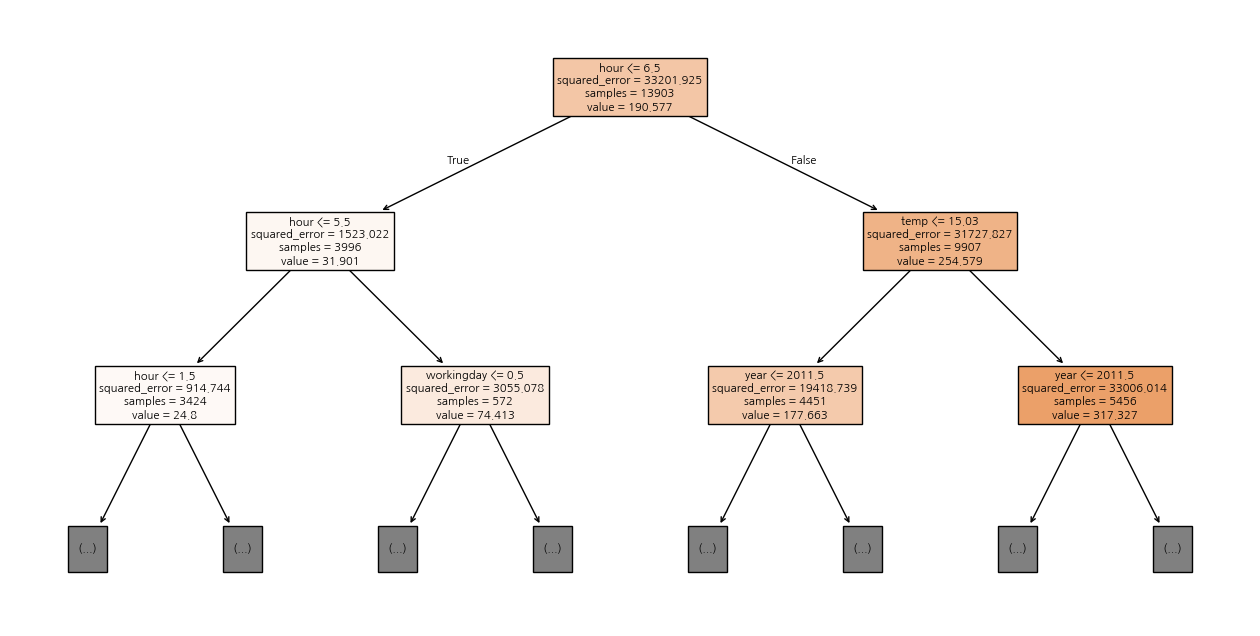

In [322]:
# 트리 구조 시각화로 "어떤 조건으로 분기하는지" 직접 확인하기
# 가장 위의 조건이 분기조건 (나머지는 현재 노드의 오차, 들어온 데이터 개수, 평균 예측값)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns, filled=True, max_depth=2)   # 너무 복잡하니 2단계까지만 표시
plt.show()


> 🚀 **실무에서는?** 이 트리를 실제로 열어보면 맨 위 분기 조건이 대부분 `hour`(시간대)로 시작합니다.
(모델이 가장 먼저 데이터를 나누기에 좋은 변수라고 판단했다는 의미 > 변수 하나씩 다 시험해본 뒤 MSE를 가장 많이 줄여주는 변수르 자동으로 선택)

> 출퇴근 시간과 한밤중의 수요 차이가 워낙 뚜렷하기 때문인데, 이렇게 트리 구조를 직접 눈으로 확인하는 것만으로도 "이 모델이 무엇을 근거로 판단하는지"를 현업 담당자에게 설명하기 훨씬 쉬워집니다.

### 4) `RandomForestRegressor` — 여러 트리의 평균 (앙상블)

- 하나의 트리가 아니라, 조금씩 다른 여러 개의 트리를 만들어서 그 예측을 평균 내는 방법
- 여러 사람의 의견을 종합하면 한 사람의 판단보다 안정적인 것과 같은 원리

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
# n_estimators=100: 트리를 100개 만들어서 평균 냄
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print(rf_pred[:5])
```

</details>

In [323]:
# 코드 입력

from sklearn.ensemble import RandomForestRegressor

# n_estimators=100: 트리를 100개 만들어서 평균 냄
# 트리가 많아지면 일반적으로 안정적이지만, 학습과 예측 시간이 늘어남
rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print(rf_pred[:5])  # 결과
print(y_test.values[:5]) # 답안지

[376.65569101  99.24038016   8.69032451 506.73658287  12.20360461]
[425  88   4 526  13]


> 🔮 **예측해보세요**: Feature Importance(특성 중요도)를 확인하기 전에, 자전거 수요에 가장 큰 영향을 줄 것 같은 특성 3개를 스스로 먼저 꼽아보세요. 시간대일까요? 기온일까요? 아래 결과와 비교해보세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 어떤 특성이 예측에 중요했는지 확인 (Feature Importance, CH03-03에서 자세히 다룸)
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(8))
```

</details>

In [324]:
# 어떤 특성이 예측에 중요했는지 확인 (Feature Importance, CH13에서 자세히 다룸)
# feature_importances_
importance = pd.Series(rf_model.feature_importances_, index = X.columns).sort_values(ascending=False)
print(importance.head(8))

# weather_rain     0.008944
# 이런 결과를 보고 생각해봐야 함
# 비가 온다고 했지만 실제로는 비가 안 왔다거나 비가 조금만 왔거나, 등등...

hour             0.673946
temp             0.125992
year             0.094336
workingday       0.052883
season_spring    0.014324
feel_temp        0.009548
weather_rain     0.008944
humidity         0.006460
dtype: float64


### 5) `GradientBoostingRegressor` — 이전 모델의 오차를 보완해가는 앙상블

- 트리를 한 번에 여러 개 만드는 RandomForest와 달리, 트리를 하나씩 순서대로 만들며 이전 트리가 "틀린 부분"을 다음 트리가 보완
- 출근 시간대 예측이 계속 빗나간다면, 다음 트리는 그 오차를 줄이는 데 집중

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
print(gb_pred[:5])
```

</details>

In [325]:
# 코드 입력

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
print(gb_pred[:5])


[476.9283274  125.28271395  43.87470375 509.77097633   7.94076547]


### 6) `XGBRegressor` — 그래디언트 부스팅을 더 빠르고 정교하게

- GradientBoosting의 아이디어를 훨씬 빠르고 성능 좋게 구현한 라이브러리
- 정형 데이터(표 형태) 예측 대회에서 가장 많이 우승하는 모델 계열

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# pip install xgboost 필요
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print(xgb_pred[:5])
```

</details>

In [326]:
# xgboost 없다면 설치!
# !pip insatll xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train) # 모델 학습

xgb_pred = xgb_model.predict(X_test)  # 예측
print(xgb_pred[:5]) # 결과


[393.9563   116.06704   16.186796 545.5777     8.505891]


### 7) 서로 다른 방식 비교 — 선형 모델 vs 트리 기반 모델

| 구분 | 선형 모델 (LinearRegression) | 트리 기반 모델 (Tree, RF, GB, XGB) |
|---|---|---|
| 관계 가정 | 특성과 결과가 "직선적인" 관계라고 가정 | 복잡하고 비선형적인 관계도 자동으로 포착 |
| 해석 용이성 | 계수(coef_)로 매우 직관적인 해석 가능 | 상대적으로 해석이 어려움 (Feature Importance로 일부 보완) |
| 시간대처럼 주기적인 패턴 | 잘 못 잡아냄 (0시와 23시가 "멀다"고 착각) | 조건 분기라서 비교적 유연하게 포착 |
| 데이터 스케일링 필요성 | 필요한 경우가 많음(CH02-05 복습) | 트리 기반은 스케일링에 비교적 자유로움 |
| 일반적 성능 | 관계가 단순할 때 충분히 좋음 | 복잡한 패턴에서 대체로 더 높은 성능 |

> 💡 **핵심 요약**: 우리 자전거 수요 데이터처럼 "출퇴근 시간대에만 반짝 수요가 몰리는" 비선형적 패턴이 강한 경우, 트리 기반 앙상블 모델이 선형회귀보다 대체로 더 좋은 성능을 냅니다. 그럼에도 실무에서는 선형회귀로 베이스라인을 먼저 잡고, 트리 기반 모델로 성능을 끌어올리는 순서로 진행하는 것이 표준적입니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ `fit()`을 하기 전에 `predict()`를 호출해서 에러가 나는 경우가 있습니다 — 반드시 `fit()`(학습) 후 `predict()`(예측) 순서를 지켜야 합니다.

> ⚠️ 테스트 데이터로 다시 `fit()`을 호출해서 모델을 재학습시키는 경우가 있습니다 — 테스트 데이터는 `predict()`에만 사용해야 합니다.

> ⚠️ 범주형 컬럼(`season`, `weather`)을 인코딩하지 않고 그대로 모델에 넣으면 에러가 발생합니다 — CH10에서 배운 인코딩을 반드시 먼저 적용해야 합니다.

---

## 🚀 실무에서는?

> 🚀 실무에서는 보통 선형회귀로 베이스라인(기준 성능)을 먼저 잡고, RandomForest·XGBoost 같은 트리 기반 앙상블로 성능을 끌어올리는 순서로 진행합니다. 특히 수요 예측처럼 시간·요일·계절에 따라 패턴이 반복되는 문제에서는 XGBoost(및 유사 라이브러리인 LightGBM)가 정형 데이터 대회에서 가장 많이 우승하는 모델 계열입니다.

---

## 🧩 Check Point

**Q1.** 여러 트리를 순차적으로 만들어 이전 트리의 오차를 보완하는 방식은? ① RandomForest ② GradientBoosting ③ LinearRegression ④ DecisionTree
<details><summary>정답</summary>② GradientBoosting</details>

**Q2.** 모델의 계수를 통해 각 특성의 영향력을 가장 직관적으로 해석할 수 있는 모델은? ① RandomForest ② XGBoost ③ LinearRegression ④ DecisionTree
<details><summary>정답</summary>③ LinearRegression</details>

**Q3.** 시간대(hour)처럼 0시와 23시가 사실은 "붙어있는" 값을 선형회귀가 잘 다루지 못하는 이유는 무엇일까요? (생각해보고 정답 확인)
<details><summary>정답</summary>선형회귀는 숫자의 크기 순서를 그대로 직선 관계로 해석하기 때문에, 23 다음에 다시 0으로 돌아가는 "주기성"을 포착하지 못하고 0시와 23시를 가장 먼 값으로 취급합니다. 반면 트리 기반 모델은 조건 분기 방식이라 이런 제약이 상대적으로 적습니다.</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다. (정규 수업이 아닌 **자습 시간**에 진행합니다.)

In [327]:
# TODO 1 (데이터 준비): bike_sharing_hourly.csv를 불러와 인코딩 후 train_test_split으로 나누세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("bike_sharing_hourly.csv")
df_encoded = pd.get_dummies(df, columns=["season", "weather"], drop_first=True)
df_encoded["holiday"] = df_encoded["holiday"].astype(int)
df_encoded["workingday"] = df_encoded["workingday"].astype(int)

X = df_encoded.drop(columns=["count"])
y = df_encoded["count"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
```

</details>

In [328]:
# 코드 입력

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('bike_sharing_hourly.csv')
# df.head()
# df.info()

df_encoded = pd.get_dummies(df, columns=['season', 'weather'], drop_first=True)

X = df_encoded.drop(columns=['count'])  # count 빼고 다
y = df_encoded['count'] # count만
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(13903, 16) (3476, 16)


In [329]:
# TODO 2 (LinearRegression): 선형회귀 모델을 학습시키고 처음 5개 예측값을 출력하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
print(lr.predict(X_test)[:5])
```

</details>

In [330]:
# 코드 입력
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, y_train)  # 학습
print(lr.predict(X_test)[:5]) # 예측값


[435.9815115  192.3367255   60.95514004 410.97528775 -22.76401086]


In [331]:
# TODO 3 (DecisionTreeRegressor): max_depth=4로 트리 회귀 모델을 학습시키세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
print(tree.predict(X_test)[:5])
```

</details>

In [332]:
# 코드 입력

from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(max_depth=4, random_state=42)

tree.fit(X_train, y_train)
print(tree.predict(X_test)[:5])


[417.93694078 126.81081081  11.28562134 417.93694078  26.04225352]


In [333]:
# TODO 4 (RandomForestRegressor): 트리 100개로 랜덤포레스트를 학습시키고 특성 중요도 상위 5개를 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(5))
```

</details>

In [334]:
# 코드 입력

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)

rf.fit(X_train, y_train)
# rf.feature_importances_를 통해 각 특성의 중요도를 추출
# pandas Series로 변환하여 중요도 순서대로 정렬
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(5))


hour             0.673946
temp             0.125992
year             0.094336
workingday       0.052883
season_spring    0.014324
dtype: float64


In [335]:
# TODO 5 (GradientBoosting/XGBoost): 두 모델을 각각 학습시켜 예측값을 비교하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

print("GB:", gb.predict(X_test)[:5])
print("XGB:", xgb.predict(X_test)[:5])
```

</details>

In [336]:
# 코드 입력

from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

print("GB:", gb.predict(X_test)[:5])
print("XGB:", xgb.predict(X_test)[:5])


GB: [476.9283274  125.28271395  43.87470375 509.77097633   7.94076547]
XGB: [393.9563   116.06704   16.186796 545.5777     8.505891]


---

## 📝 실습 과제

> 📝 아래 과제도 **자습 시간**에 진행합니다.

In [337]:
# 과제 1
# DecisionTreeRegressor의 max_depth를 2, 5, 10으로 각각 바꿔가며 학습시키고
# 예측값이 어떻게 달라지는지 비교하세요


# 과제 2
# 출근 시간대(7~9시)와 심야 시간대(1~4시)만 따로 골라서 RandomForestRegressor를 학습시키고,
# 전체 데이터로 학습한 모델과 출근시간대 예측 정확도가 어떻게 다른지 비교하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.tree import DecisionTreeRegressor
for depth in [2, 5, 10]:
    t = DecisionTreeRegressor(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    print(f"max_depth={depth}:", t.predict(X_test)[:3])
```

</details>

In [338]:
# 과제 1 답안

from sklearn.tree import DecisionTreeRegressor
for depth in [2,5,10]:
    t = DecisionTreeRegressor(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    print(f'max_depth={depth}:', t.predict(X_test)[:3])


max_depth=2: [317.32679619 177.66344642  24.79964953]
max_depth=5: [522.93289329 165.35510204   6.46566901]
max_depth=10: [394.56756757  90.33333333  10.        ]


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf_full = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_full.fit(X_train, y_train)

rush_mask = X_test["hour"].isin([7, 8, 9])
rush_pred = rf_full.predict(X_test[rush_mask])
print("출근시간대 MAE:", mean_absolute_error(y_test[rush_mask], rush_pred))
print("전체 MAE:", mean_absolute_error(y_test, rf_full.predict(X_test)))
```

</details>

In [339]:
# 과제 2 답안
# 출근 시간대(7~9시)와 심야 시간대(1~4시)만 따로 골라서 RandomForestRegressor를 학습시키고,
# 전체 데이터로 학습한 모델과 출근시간대 예측 정확도가 어떻게 다른지 비교하세요

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf_full = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_full.fit(X_train, y_train)

rush_mask = X_test['hour'].isin([7,8,9])
rush_pred = rf_full.predict(X_test[rush_mask])

print('출근시간대 MAE:', mean_absolute_error(y_test[rush_mask], rush_pred))
print('전체 MAE:', mean_absolute_error(y_test, rf_full.predict(X_test)))



출근시간대 MAE: 60.479236389628696
전체 MAE: 40.96506229857192


---

## 📌 핵심 정리

- `LinearRegression`: 직선적 관계 가정, 계수로 해석 용이, 주기적 패턴(시간대)에 약함
- `DecisionTreeRegressor`: 조건 분기로 예측, 구조를 시각화해 설명 가능
- `RandomForestRegressor`: 여러 트리의 평균, 안정적 성능, Feature Importance 제공
- `GradientBoostingRegressor` / `XGBRegressor`: 오차를 순차적으로 보완, 대체로 가장 높은 성능

# 📘 CH12-02. 회귀 모델 평가

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 왜 평가가 필요한가 → MAE → MSE → RMSE → R² Score → 여러 모델 비교 → MAE vs MSE(폭설로 인한 이례적인 하루)
> 🔧 **실습파일**: 필요
> ⏱️ **예상 소요시간**: 55분 이상
> 🎚️ **난이도**: ★★★★☆
> 🔗 **사전 지식**: CH03-02-01

---

## 🤔 먼저 생각해보기

> **앞서 만든 4개 모델(Linear, Tree, RF, GB/XGB) 중 어떤 모델을 운영팀에 넘겨야 할까요? "그냥 예측값 몇 개를 눈으로 비교"하는 것 말고, 숫자로 확실하게 말할 방법이 필요합니다.**

예측이 틀렸을 때 그 "틀린 정도"를 하나의 숫자로 요약하는 것이 평가지표입니다. 이번 챕터에서는 회귀 모델을 평가하는 4가지 대표 지표를 우리 자전거 수요 예측 결과에 직접 적용해봅니다.

### 1) 왜 평가가 필요한가?

- "예측값과 실제값이 대충 비슷해 보인다"는 감이 아니라, 객관적인 숫자로 모델을 비교해야 함
- 운영팀에게 "이 모델은 평균 15대 정도 오차가 납니다"처럼 구체적으로 보고할 수 있어야 신뢰를 얻음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 앞서 학습한 4개 모델의 예측값을 다시 확인
print(lr_pred[:3], tree_pred[:3], rf_pred[:3], gb_pred[:3])
```

</details>

In [340]:
# 코드 입력

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 앞서 학습한 4개 모델의 예측값을 다시 확인
print(lr_pred[:3], tree_pred[:3], rf_pred[:3], gb_pred[:3])


[435.9815115  192.3367255   60.95514004] [417.93694078 126.81081081  11.28562134] [376.65569101  99.24038016   8.69032451] [476.9283274  125.28271395  43.87470375]


### 2) MAE (Mean Absolute Error, 평균 절대 오차)

- 예측값과 실제값의 차이(오차)에 절댓값을 씌운 뒤 평균
- "평균적으로 몇 대나 틀렸는지"를 그대로 대여량 단위(대)로 알려줘서 운영팀에게 설명하기 가장 쉬움

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
mae_lr = mean_absolute_error(y_test, lr_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)
print(f"LinearRegression MAE: {mae_lr:.2f}대")
print(f"RandomForest MAE: {mae_rf:.2f}대")
```

</details>

In [341]:
# 코드 입력
# mean_absolute_error(답안지, 예측한 값)
mae_lr = mean_absolute_error(y_test, lr_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)

print(f'LinearRegression MAE: {mae_lr:.2f}대')
print(f'RandomForest MAE: {mae_rf:.2f}대')


LinearRegression MAE: 103.74대
RandomForest MAE: 40.97대


### 3) MSE (Mean Squared Error, 평균 제곱 오차)

- 오차를 제곱한 뒤 평균 → 큰 오차에 훨씬 더 큰 벌점을 줌
- "자전거가 30대나 부족했던 날"처럼 크게 틀린 예측을 더 강하게 반영

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
mse_lr = mean_squared_error(y_test, lr_pred)
mse_rf = mean_squared_error(y_test, rf_pred)
print(f"LinearRegression MSE: {mse_lr:.2f}")
print(f"RandomForest MSE: {mse_rf:.2f}")
```

</details>

In [342]:
# 코드 입력

mse_lr = mean_squared_error(y_test, lr_pred)
mse_rf = mean_squared_error(y_test, rf_pred)

print(f"LinearRegression MSE: {mse_lr:.2f}")
print(f"RandomForest MSE: {mse_rf:.2f}")

LinearRegression MSE: 19021.31
RandomForest MSE: 4027.07


### 4) RMSE (Root Mean Squared Error, 평균 제곱근 오차)

- MSE에 제곱근을 씌워 원래 단위(대)로 되돌린 지표 — MSE보다 해석이 쉬움

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# sklearn 최신 버전에서는 squared=False 옵션 대신 root_mean_squared_error 함수 제공
rmse_lr = root_mean_squared_error(y_test, lr_pred)
rmse_rf = root_mean_squared_error(y_test, rf_pred)
print(f"LinearRegression RMSE: {rmse_lr:.2f}대")
print(f"RandomForest RMSE: {rmse_rf:.2f}대")
```

</details>

In [343]:
# sklearn 최신 버전에서는 squared=False 옵션 대신 root_mean_squared_error 함수 제공
rmse_lr = root_mean_squared_error(y_test, lr_pred)
rmse_rf = root_mean_squared_error(y_test, rf_pred)

# np.sqrt() 활용
import numpy as np
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"LinearRegression RMSE: {rmse_lr:.2f}대")
print(f"RandomForest RMSE: {rmse_rf:.2f}대")


LinearRegression RMSE: 137.92대
RandomForest RMSE: 63.46대


### 5) R² Score (결정계수)

- 모델이 대여량의 "변동성"을 얼마나 설명하는지 0~1 사이 비율로 표현 (1에 가까울수록 좋음)
- "기온만 알아도 대충 맞히는 수준(0에 가까움)"인지 "패턴을 거의 다 잡아낸 수준(1에 가까움)"인지 판단
- 그냥 대충 평균값을 다 넣은 것보다 못하면 0
- 0보다 작으면 평균값보다 못한 것

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
r2_lr = r2_score(y_test, lr_pred)
r2_rf = r2_score(y_test, rf_pred)
print(f"LinearRegression R2: {r2_lr:.3f}")
print(f"RandomForest R2: {r2_rf:.3f}")
```

</details>

In [344]:
# 코드 입력

r2_lr = r2_score(y_test, lr_pred)
r2_rf = r2_score(y_test, rf_pred)

print(f"LinearRegression R2: {r2_lr:.3f}")
print(f"RandomForest R2: {r2_rf:.3f}")


LinearRegression R2: 0.399
RandomForest R2: 0.873


> 🔮 **예측해보세요**: 위 R² 값을 확인하기 전에, 시간대·날씨 정보만으로 자전거 수요를 얼마나 잘 맞힐 수 있을지 0~1 사이로 스스로 추측해보세요. 트리 기반 모델이 선형모델보다 얼마나 더 높을지도 함께 예상해보고 비교해보세요.

### 6) 여러 모델을 한 번에 비교하기

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd

results = pd.DataFrame({
    "모델": ["LinearRegression", "DecisionTree", "RandomForest", "GradientBoosting", "XGBoost"],
    "MAE": [mean_absolute_error(y_test, lr_pred), mean_absolute_error(y_test, tree_pred),
            mean_absolute_error(y_test, rf_pred), mean_absolute_error(y_test, gb_pred),
            mean_absolute_error(y_test, xgb_pred)],
    "RMSE": [root_mean_squared_error(y_test, lr_pred), root_mean_squared_error(y_test, tree_pred),
             root_mean_squared_error(y_test, rf_pred), root_mean_squared_error(y_test, gb_pred),
             root_mean_squared_error(y_test, xgb_pred)],
    "R2": [r2_score(y_test, lr_pred), r2_score(y_test, tree_pred),
           r2_score(y_test, rf_pred), r2_score(y_test, gb_pred),
           r2_score(y_test, xgb_pred)],
})
print(results.sort_values("R2", ascending=False))
```

</details>

In [345]:
# 코드 입력

import pandas as pd

results = pd.DataFrame({
    "모델": ["LinearRegression", "DecisionTree", "RandomForest", "GradientBoosting", "XGBoost"],
    "MAE": [mean_absolute_error(y_test, lr_pred), mean_absolute_error(y_test, tree_pred),
            mean_absolute_error(y_test, rf_pred), mean_absolute_error(y_test, gb_pred),
            mean_absolute_error(y_test, xgb_pred)],
    "RMSE": [root_mean_squared_error(y_test, lr_pred), root_mean_squared_error(y_test, tree_pred),
             root_mean_squared_error(y_test, rf_pred), root_mean_squared_error(y_test, gb_pred),
             root_mean_squared_error(y_test, xgb_pred)],
    "R2": [r2_score(y_test, lr_pred), r2_score(y_test, tree_pred),
           r2_score(y_test, rf_pred), r2_score(y_test, gb_pred),
           r2_score(y_test, xgb_pred)],
})
print(results.sort_values("R2", ascending=False))


                 모델         MAE        RMSE        R2
4           XGBoost   25.025852   40.342010  0.948604
2      RandomForest   40.965062   63.459169  0.872824
3  GradientBoosting   45.834098   67.058214  0.857990
1      DecisionTree   80.214021  117.072220  0.567165
0  LinearRegression  103.739280  137.917773  0.399303


### MSE는?
- 제곱된 단위(대²) 가 되어버림. 따라서 1,625(대²) 라고 하면 직관적으로 이해하기 어려움
- 반면, RMSE는 '평균 40대 정도 틀린다.'로 표현하기 때문에 해석이 쉬움


### 7) 서로 다른 방식 비교 — MAE vs MSE (이상치 민감도)

> 🚀 **실무 시나리오**: 2012년 10월 29일, 워싱턴 D.C.에 대형 허리케인(샌디)이 상륙하면서 자전거 대여량이 평소의 10분의 1 수준으로 급감한 날이 있었습니다. 이런 "이례적인 하루"가 섞여 있으면 평가지표가 어떻게 달라질까요?

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import numpy as np

# 이례적으로 튄 값 하나(허리케인급 이변)가 포함된 가상의 예측 결과로 비교
y_true_sample = np.array([120, 80, 95, 110, 5])     # 마지막 값은 이례적 폭풍우로 실제 대여량이 5대까지 급감
y_pred_sample = np.array([115, 85, 90, 105, 90])    # 모델은 폭풍우를 몰라서 평소처럼 90대로 예측 (많이 틀림)

print("MAE:", mean_absolute_error(y_true_sample, y_pred_sample))
print("MSE:", mean_squared_error(y_true_sample, y_pred_sample))
```

</details>

In [346]:
# 코드 입력

import numpy as np

# 이례적으로 튄 값 하나(허리케인급 이변)가 포함된 가상의 예측 결과로 비교
y_true_sample = np.array([120, 80, 95, 110, 5])     # 마지막 값은 이례적 폭풍우로 실제 대여량이 5대까지 급감
y_pred_sample = np.array([115, 85, 90, 105, 90])    # 모델은 폭풍우를 몰라서 평소처럼 90대로 예측 (많이 틀림)

print("MAE:", mean_absolute_error(y_true_sample, y_pred_sample))
print("MSE:", mean_squared_error(y_true_sample, y_pred_sample))


MAE: 21.0
MSE: 1465.0


> 💡 마지막 값 하나의 오차(85)가 MSE를 얼마나 크게 끌어올리는지 확인해보세요. 이런 "이례적인 하루"가 실무 데이터에 섞여 있다면, MSE/RMSE는 그 영향을 크게 반영하고 MAE는 상대적으로 덜 민감합니다. 어떤 지표를 기준으로 모델을 고를지는 "이례적인 상황을 얼마나 심각하게 볼 것인가"에 달려 있습니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ MAE와 MSE의 단위를 착각하는 경우가 많습니다 — MSE는 제곱 단위라서 원래 대여량(대) 단위와 직접 비교할 수 없고, RMSE로 되돌려야 비교 가능합니다.

> ⚠️ R²가 음수로 나올 수 있다는 걸 모르고 당황하는 경우가 있습니다 — 모델이 "평균으로만 찍는 것"보다도 못할 때 음수가 나올 수 있습니다.

---

## 🚀 실무에서는?

> 🚀 실무에서는 보통 MAE와 RMSE를 함께 보고합니다. MAE는 "평균적으로 몇 대 틀렸는지"를 직관적으로 보여주고, RMSE는 "이례적으로 크게 틀린 날이 있었는지"를 함께 알려주기 때문입니다. 자전거 재고처럼 "크게 틀리면 손해가 급격히 커지는" 운영 문제에서는 RMSE 비중을 더 두는 경우가 많습니다.

---

## 🧩 Check Point

**Q1.** 이상치(이례적으로 크게 틀린 예측)에 더 민감하게 반응하는 지표는? ① MAE ② MSE
<details><summary>정답</summary>② MSE (제곱을 하기 때문에 큰 오차가 훨씬 크게 반영됨)</details>

**Q2.** R² Score가 1에 가깝다는 것은 무슨 의미일까요? ① 오차가 매우 크다 ② 모델이 데이터의 패턴을 잘 설명한다 ③ 데이터가 적다는 뜻이다
<details><summary>정답</summary>② 모델이 데이터의 패턴을 잘 설명한다</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. (자습 시간에 진행합니다.)

In [347]:
# TODO 1 (MAE/MSE): RandomForest 모델의 MAE와 MSE를 각각 계산하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
```

</details>

In [348]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))

MAE: 40.96506229857192
MSE: 4027.0661189674975


In [349]:
# TODO 2 (RMSE): GradientBoosting 모델의 RMSE를 계산하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import root_mean_squared_error
print("RMSE:", root_mean_squared_error(y_test, gb_pred))
```

</details>

In [350]:
# 코드 입력

from sklearn.metrics import root_mean_squared_error
print("RMSE:", root_mean_squared_error(y_test, gb_pred))


RMSE: 67.05821448543682


In [351]:
# TODO 3 (R2): 5개 모델의 R² Score를 각각 계산해서 어떤 모델이 가장 높은지 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import r2_score
preds = {"Linear": lr_pred, "Tree": tree_pred, "RF": rf_pred, "GB": gb_pred, "XGB": xgb_pred}
for name, pred in preds.items():
    print(name, r2_score(y_test, pred))
```

</details>

In [352]:
# 코드 입력

from sklearn.metrics import r2_score
preds = {"Linear": lr_pred, "Tree": tree_pred, "RF": rf_pred, "GB": gb_pred, "XGB": xgb_pred}
for name, pred in preds.items():
    print(name, r2_score(y_test, pred))


Linear 0.39930317328797316
Tree 0.5671647965499281
RF 0.8728244494859572
GB 0.8579900294932336
XGB 0.9486039280891418


In [353]:
# TODO 4 (종합 비교표): 5개 모델의 MAE/MSE/RMSE/R2를 모두 담은 DataFrame을 만드세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

preds = {"Linear": lr_pred, "Tree": tree_pred, "RF": rf_pred, "GB": gb_pred, "XGB": xgb_pred}
rows = []
for name, pred in preds.items():
    rows.append({
        "모델": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    })
print(pd.DataFrame(rows))
```

</details>

In [354]:
# 코드 입력

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

preds = {"Linear": lr_pred, "Tree": tree_pred, "RF": rf_pred, "GB": gb_pred, "XGB": xgb_pred}
rows = []
for name, pred in preds.items():
    rows.append({
        "모델": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    })
print(pd.DataFrame(rows))


       모델         MAE           MSE        RMSE        R2
0  Linear  103.739280  19021.312106  137.917773  0.399303
1    Tree   80.214021  13705.904758  117.072220  0.567165
2      RF   40.965062   4027.066119   63.459169  0.872824
3      GB   45.834098   4496.804130   67.058214  0.857990
4     XGB   25.025852   1627.477905   40.342010  0.948604


---

## 📝 실습 과제

> 📝 자습 시간에 진행합니다.

In [355]:
# 과제 1
# 출근 시간대(7~9시)만 따로 골라 RandomForest의 MAE를 계산하고,
# 전체 데이터 MAE와 비교하세요

# 과제 2
# 훈련 데이터와 테스트 데이터 각각에 대해 RandomForest의 R2를 계산하고,
# 두 값의 차이가 크다면(과대적합 의심) 그 이유를 생각해보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import mean_absolute_error
rush_mask = X_test["hour"].isin([7, 8, 9])
print("출근시간대 MAE:", mean_absolute_error(y_test[rush_mask], rf_model.predict(X_test[rush_mask])))
print("전체 MAE:", mean_absolute_error(y_test, rf_pred))
```

</details>

In [356]:
# 과제 1 답안

from sklearn.metrics import mean_absolute_error
rush_mask = X_test["hour"].isin([7, 8, 9])
print("출근시간대 MAE:", mean_absolute_error(y_test[rush_mask], rf_model.predict(X_test[rush_mask])))
print("전체 MAE:", mean_absolute_error(y_test, rf_pred))


출근시간대 MAE: 60.479236389628696
전체 MAE: 40.96506229857192


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import r2_score
train_r2 = r2_score(y_train, rf_model.predict(X_train))
test_r2 = r2_score(y_test, rf_pred)
print("훈련 R2:", train_r2, "/ 테스트 R2:", test_r2)
# 훈련 R2가 테스트 R2보다 훨씬 높다면 과대적합(CH03-01-04)을 의심해볼 수 있음
```

</details>

In [357]:
# 과제 2 답안

from sklearn.metrics import r2_score
train_r2 = r2_score(y_train, rf_model.predict(X_train))
test_r2 = r2_score(y_test, rf_pred)
print("훈련 R2:", train_r2, "/ 테스트 R2:", test_r2)


훈련 R2: 0.8809788852288903 / 테스트 R2: 0.8728244494859572


---

## 📌 핵심 정리

- MAE: 절대 오차 평균, 이상치에 덜 민감, 단위 그대로 해석 가능
- MSE: 오차 제곱 평균, 이상치(크게 틀린 예측)에 민감
- RMSE: MSE에 제곱근, 원래 단위로 해석 가능
- R2: 0~1, 모델이 데이터 변동성을 설명하는 정도

---

# 🖥️ 라이브 데모 — 결정트리가 "움직이는 그림"

> ⏭️ 이 섹션은 진도 상황에 따라 건너뛸 수 있는 독립 코너입니다.

오전 내내 코드로만 다뤘던 결정트리가 실제로 데이터를 어떻게 갈라내는지, 세계적으로 유명한 인터랙티브 시각화로 직접 확인해봅니다.

**🔗 접속 주소**: [A Visual Introduction to Machine Learning (R2D3)](https://r2d3.us/visual-intro-to-machine-learning-part-1/)

**함께 보는 포인트**
1. 샌프란시스코 vs 뉴욕의 집을 분류하는 문제 — 오늘 오후에 우리가 풀 "분류" 문제와 같은 구조입니다.
2. 스크롤을 내리면 트리가 한 단계씩 분기하며 데이터를 갈라내는 과정이 애니메이션으로 펼쳐집니다.
3. 마지막 부분의 훈련/테스트 정확도 차이 — 다음 시간(CH03-03)에 배울 과대적합의 예고편입니다.

**✏️ 자유 체험**: 채팅으로 공유된 링크에 접속해 각자 스크롤을 내리며 감상해보세요. 인상 깊은 장면이 있다면 채팅에 자유롭게 남겨주세요. (한국어 버전도 지원됩니다 — 페이지 상단에서 언어 선택 가능)

> 💡 예비 링크: [MLU-Explain (Amazon)](https://mlu-explain.github.io/) — Random Forest, Precision/Recall 등 오늘 배우는 개념들의 인터랙티브 에세이 모음

# 📘 CH12-03. 분류 모델

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 오후의 미션 소개 → 데이터 준비(직원 퇴사) → Logistic Regression → Decision Tree Classifier → Random Forest Classifier → XGBoost Classifier → 비교
> 🔧 **실습파일**: 필요 (`hr_attrition.csv` — 사전 배포)
> ⏱️ **예상 소요시간**: 55분 이상
> 🎚️ **난이도**: ★★★★★
> 🔗 **사전 지식**: CH03-02-01, CH03-02-02, CH09(자료형·불필요 컬럼 정리), CH10(인코딩)

---

## 🤔 먼저 생각해보기

> **오전에는 회귀로 "숫자"를 예측했다면, 이제 여러분은 대기업 OO전자의 인사(HR)팀으로 파견되었습니다. 이번 요청은 이렇습니다 — "다음 분기에 퇴사할 것 같은 직원을 미리 찾아서, 팀장 면담과 처우 개선을 먼저 제안할 수 있게 해주세요." 이번엔 숫자가 아니라 "퇴사한다 / 안 한다"라는 카테고리를 맞혀야 합니다. 무엇이 달라질까요?**

회귀와 분류는 예측 대상만 다를 뿐, 모델을 학습시키고 평가하는 전체적인 흐름은 매우 비슷합니다. 이번 챕터에서는 실제 기업 HR 데이터로 대표적인 분류 모델 4가지를 학습시켜, "퇴사 가능성이 높은 직원"을 실제로 골라내 봅니다.

> 💡 이번 챕터는 IBM 데이터 과학자들이 공개한 HR 데이터(IBM HR Analytics Employee Attrition, 직원 1,470명 × 특성 30여 개)를 사용합니다. 연봉, 야근 여부, 통근 거리, 직무 만족도, 워라밸 점수까지 포함된 퇴사 예측 문제의 정석 데이터셋입니다. 취업을 준비하는 여러분 입장에서도 "회사는 어떤 직원이 떠날지 이런 데이터로 들여다본다"는 걸 체험해볼 수 있는 소재입니다.

### 0) 데이터 준비 — 직원 퇴사(Attrition) 데이터

- 인적 정보(`Age`, `Gender`, `MaritalStatus`), 직무 정보(`Department`, `JobRole`, `JobLevel`), 근무 조건(`OverTime` 야근 여부, `DistanceFromHome` 통근 거리, `MonthlyIncome` 월급), 만족도(`JobSatisfaction`, `WorkLifeBalance`, `EnvironmentSatisfaction`) 등 30여 개 특성
- 목표값(`Attrition`): 이 직원이 퇴사했는지 여부 (Yes/No → 이진 분류 문제)
- 파일은 노트북과 같은 폴더에 두고 실행하세요 (Colab이라면 왼쪽 파일 탭에 업로드)

<details>
<summary><b>📋 HR Attrition 컬럼 설명</b></summary>

| 컬럼 | 설명 | 값 |
|------|------|------|
| Age | 직원 나이 | 18~60세 |
| Attrition | 퇴사 여부 | Yes(퇴사), No(재직) |
| BusinessTravel | 출장 빈도 | Non-Travel, Travel_Rarely, Travel_Frequently |
| DailyRate | 일일 급여 지표 | 숫자 (내부 지표) |
| Department | 부서 | Sales, Research & Development, Human Resources |
| DistanceFromHome | 집-회사 거리 | 마일(Miles) |
| Education | 최종 학력 | 1: Below College, 2: College, 3: Bachelor, 4: Master, 5: Doctor |
| EducationField | 전공 분야 | Life Sciences, Medical, Marketing, Technical Degree, Human Resources, Other |
| EmployeeCount | 직원 수 | 항상 1 |
| EmployeeNumber | 직원 고유번호 | 정수 |
| EnvironmentSatisfaction | 근무 환경 만족도 | 1: 낮음, 2: 보통, 3: 높음, 4: 매우 높음 |
| Gender | 성별 | Male, Female |
| HourlyRate | 시간당 급여 지표 | 숫자 (내부 지표) |
| JobInvolvement | 업무 몰입도 | 1: 낮음, 2: 보통, 3: 높음, 4: 매우 높음 |
| JobLevel | 직급 | 1~5 (높을수록 고위직) |
| JobRole | 직무 | Sales Executive, Research Scientist, Laboratory Technician 등 |
| JobSatisfaction | 직무 만족도 | 1: 낮음, 2: 보통, 3: 높음, 4: 매우 높음 |
| MaritalStatus | 결혼 여부 | Single, Married, Divorced |
| MonthlyIncome | 월급 | 달러($) |
| MonthlyRate | 월 급여 지표 | 숫자 (내부 지표) |
| NumCompaniesWorked | 이전 직장 수 | 정수 |
| Over18 | 18세 이상 여부 | 항상 Y |
| OverTime | 초과근무 여부 | Yes, No |
| PercentSalaryHike | 급여 인상률 | % |
| PerformanceRating | 성과 평가 | 3: Good, 4: Excellent |
| RelationshipSatisfaction | 대인관계 만족도 | 1: 낮음, 2: 보통, 3: 높음, 4: 매우 높음 |
| StandardHours | 표준 근무시간 | 항상 80시간 |
| StockOptionLevel | 스톡옵션 등급 | 0~3 |
| TotalWorkingYears | 총 경력 | 년(Years) |
| TrainingTimesLastYear | 최근 1년 교육 횟수 | 회(Times) |
| WorkLifeBalance | 일·생활 균형 | 1: 나쁨, 2: 보통, 3: 좋음, 4: 매우 좋음 |
| YearsAtCompany | 현재 회사 근속연수 | 년 |
| YearsInCurrentRole | 현재 직무 근속연수 | 년 |
| YearsSinceLastPromotion | 마지막 승진 이후 경과연수 | 년 |
| YearsWithCurrManager | 현재 관리자와 함께 근무한 연수 | 년 |

</details>

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd

# 사전 배포된 실습파일(hr_attrition.csv)을 노트북과 같은 폴더에 두고 실행하세요
df = pd.read_csv("hr_attrition.csv")
print(df.shape)
print(df.head())
print(df["Attrition"].value_counts())

# (예비) 파일이 없을 때 인터넷으로 직접 받는 방법 — 단, OpenML 서버 상황에 따라 매우 느릴 수 있음
# from sklearn.datasets import fetch_openml
# df = fetch_openml(data_id=43893, as_frame=True).frame
```

</details>

In [358]:
import pandas as pd

# 사전 배포된 실습파일(hr_attrition.csv)을 노트북과 같은 폴더에 두고 실행하세요
df = pd.read_csv("hr_attrition.csv")

print(df.shape)
display(df.head())
print(df['Attrition'].value_counts())

# (예비) 파일이 없을 때 인터넷으로 직접 받는 방법 — 단, OpenML 서버 상황에 따라 매우 느릴 수 있음
# from sklearn.datasets import fetch_openml
# df = fetch_openml(data_id=43893, as_frame=True).frame


(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Attrition
No     1233
Yes     237
Name: count, dtype: int64


> ⚠️ 이 데이터는 실제 현업 HR 시스템에서 뽑은 형태라, 예측에 아무 도움이 안 되는 컬럼들이 섞여 있습니다. `EmployeeNumber`(사번)는 단순 식별자이고, `EmployeeCount`·`StandardHours`·`Over18`은 모든 직원이 같은 값을 갖는 상수 컬럼입니다. CH09에서 배운 "불필요한 컬럼 정리"를 그대로 다시 사용해봅니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# CH09(불필요 컬럼 정리) 복습: 식별자(사번)와 상수 컬럼 제거
# errors="ignore": 혹시 해당 컬럼이 없어도 에러 없이 넘어가는 방어적 옵션
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")

# 목표값을 0/1로 변환 (Yes=퇴사=1, No=재직=0)
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
print(df.shape)
print("퇴사 비율:", df["Attrition"].mean().round(3))
```

</details>

In [359]:
# CH09(불필요 컬럼 정리) 복습: 식별자(사번)와 상수 컬럼 제거
# errors="ignore": 혹시 해당 컬럼이 없어도 에러 없이 넘어가는 방어적 옵션
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors='ignore')

# 목표값을 0/1로 변환 (Yes=퇴사=1, No=재직=0)
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

print(df.shape)
print('퇴사 비율:', df["Attrition"].mean().round(3))

# 전체 직원 중 약 16%가 퇴사한 상태


(1470, 31)
퇴사 비율: 0.161


> 🔮 **예측해보세요**: 아래에서 범주형 컬럼들을 One-Hot Encoding으로 바꾸면 특성이 몇 개로 늘어날지 먼저 짐작해보세요. (힌트: `Department`, `JobRole`, `MaritalStatus`, `OverTime` 등 범주형 컬럼이 여럿 있고, 특히 `JobRole`은 직무 종류가 9가지나 됩니다.)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# CH10-01(인코딩) 복습: 범주형 컬럼들을 한 번에 One-Hot Encoding
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
print("인코딩 후 특성 개수:", X.shape[1])

# CH03-01-03(데이터 분할) 복습: 퇴사자 비율이 낮으므로(약 16%) stratify로 비율 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
print("훈련 데이터 퇴사 비율:", y_train.mean().round(3))
```

</details>

In [360]:
# 범주형 컬럼들을 한 번에 One-Hot Encoding
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
print("인코딩 후 특성 개수:", X.shape[1])

# 퇴사자 비율이 낮으므로(약 16%) stratify로 비율 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
print("훈련 데이터 퇴사 비율:", y_train.mean().round(3))


인코딩 후 특성 개수: 44
(1176, 44) (294, 44)
훈련 데이터 퇴사 비율: 0.162


### 1) Logistic Regression (로지스틱 회귀) — 확률로 분류하기

- 이름은 회귀지만 실제로는 "퇴사할 확률"을 0~1 사이로 출력하는 분류 모델
- 확률이 0.5보다 크면 "퇴사", 작으면 "재직"으로 최종 판단

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_proba = lr_model.predict_proba(X_test)[:, 1]   # 퇴사(1)일 확률
lr_pred = lr_model.predict(X_test)
print("퇴사 확률 예시:", lr_proba[:5])
print("최종 예측:", lr_pred[:5])
```

</details>

In [361]:
# 코드 입력
from sklearn.linear_model import LogisticRegression

# max_iter : 계산 반복 횟수
lr_model = LogisticRegression(max_iter=1000)

# 학습
lr_model.fit(X_train, y_train)

# 예측
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print(lr_proba[:5])
print(lr_pred[:5])

# predict_proba: 각 클래스의 확률을 반환


[0.2170891  0.05496395 0.18936808 0.02324263 0.25145765]
[0 0 0 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2) Decision Tree Classifier — 조건 분기로 분류

- "야근(`OverTime`)을 하는데 월급이 낮고 집도 멀면 퇴사 가능성이 높다"처럼 조건을 스스로 학습

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
print(tree_pred[:5])
```

</details>

In [362]:
# 코드 입력

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
print(tree_pred[:5])


[1 0 0 0 0]


### 3) Random Forest Classifier — 여러 트리의 다수결 투표

- 여러 트리가 각자 "퇴사/재직"을 예측하고, 다수결로 최종 결정

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print(rf_pred[:5])
```

</details>

In [363]:
# 코드 입력

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

# 학습
rf_model.fit(X_train, y_train)

# 예측
rf_pred = rf_model.predict(X_test)
print(rf_pred[:5])


[1 0 0 0 0]


> 🚀 **실무에서는?** 인사팀이 실제로 면담하거나 처우 개선을 제안할 수 있는 인원은 한정적입니다. 그래서 실무에서는 `predict()`의 0/1 결과보다 `predict_proba()`로 나온 "퇴사 확률"을 기준으로 상위 N명(예: 퇴사 위험 상위 30명)에게만 우선 조치하는 방식을 훨씬 많이 사용합니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 퇴사 확률이 가장 높은 직원 5명 찾아보기
rf_proba = rf_model.predict_proba(X_test)[:, 1]
top_risk = pd.Series(rf_proba, index=X_test.index).sort_values(ascending=False).head(5)
print(top_risk)
```

</details>

In [364]:
# 퇴사 확률이 가장 높은 직원 5명 찾아보기

rf_proba = rf_model.predict_proba(X_test)[:, 1]
top_risk = pd.Series(rf_proba, index=X_test.index).sort_values(ascending=False).head(5)
print(top_risk)


688    0.891227
911    0.862330
301    0.768042
711    0.631474
357    0.580469
dtype: float64


### 4) XGBoost Classifier — 순차적 오차 보완 (분류 버전)

- 회귀에서 배운 XGBoost와 동일한 원리를 분류 문제에 적용

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 사전 설치 필요: pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print(xgb_pred[:5])
```

</details>

In [365]:
# 사전 설치 필요: pip install xgboost
# 모델 가져옴
from xgboost import XGBClassifier

# 기본 설정 파라미터를 넣어서 모델 가져옴
xgb_model = XGBClassifier(n_estimators=100, random_state=42)

# 모델 학습
xgb_model.fit(X_train, y_train)

# 예측
xgb_pred = xgb_model.predict(X_test)
print(xgb_pred[:5]) # 예측 결과 출력


[0 0 0 0 0]


### 5) 서로 다른 방식 비교 — Logistic Regression vs 트리 기반 모델

| 구분 | Logistic Regression | 트리 기반 모델 (Tree, RF, XGB) |
|---|---|---|
| 출력 형태 | 확률(0~1)을 자연스럽게 출력 | predict_proba()로 확률 확인 가능하나 계산 방식이 다름 |
| 해석 용이성 | 계수로 "어떤 요인이 퇴사를 높이는지" 해석 용이 | Feature Importance로 일부 보완 |
| 비선형 패턴 | 상대적으로 약함 | 강함 (조건 조합을 자동으로 포착) |
| 일반적 성능 | 베이스라인으로 적합 | 대체로 더 높은 성능 |

> 💡 **핵심 요약**: 회귀와 마찬가지로, 분류에서도 Logistic Regression으로 베이스라인을 잡고 트리 기반 모델로 성능을 끌어올리는 흐름이 표준적입니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ `EmployeeNumber`(사번)처럼 예측에 아무 의미 없는 식별자 컬럼을 특성에 포함시키는 경우가 있습니다 — 모델이 사번을 "외워버리는" 과대적합의 원인이 됩니다.

> ⚠️ `EmployeeCount`처럼 모든 행이 같은 값인 상수 컬럼은 예측에 어떤 정보도 주지 못합니다 — 미리 제거하는 습관이 필요합니다.

> ⚠️ 퇴사자 비율이 낮은(약 16%) 불균형 데이터인데 `stratify` 없이 분할하면, 훈련/테스트 데이터의 퇴사자 비율이 서로 달라질 수 있습니다.

---

## 🚀 실무에서는?

> 🚀 실무의 퇴사 예측(HR Analytics)에서는 모델 하나만 만들고 끝나지 않습니다. 예측 결과를 바탕으로 "퇴사 위험 상위 몇 %에게 어떤 조치(면담, 연봉 조정, 부서 이동)를 할 것인가", "그 비용 대비 인재 유지 효과가 있는가"까지 이어지는 것이 진짜 프로젝트의 완성입니다. 특히 HR 데이터는 민감한 개인정보라서, 예측 결과를 "누구를 감시할지"가 아니라 "어떤 근무 환경을 개선할지"에 쓰는 윤리적 기준도 실무에서 매우 중요합니다.

---

## 🧩 Check Point

**Q1.** 직원이 퇴사할 확률을 직접 확인하고 싶을 때 사용하는 메서드는? ① predict() ② predict_proba() ③ fit() ④ transform()
<details><summary>정답</summary>② predict_proba()</details>

**Q2.** 인사팀의 면담 가능 인원이 한정적일 때, 0/1 예측보다 확률 기반 상위 N명을 뽑는 방식이 더 실무적인 이유는 무엇일까요?
<details><summary>정답</summary>0.5를 기준으로 한 이분법적 판단보다, 퇴사 확률이 가장 높은 순서대로 제한된 리소스(면담 시간, 처우 개선 예산)를 우선 배분할 수 있기 때문입니다.</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. (자습 시간에 진행합니다.)

In [366]:
# TODO 1 (데이터 준비): hr_attrition.csv를 불러와 전처리(불필요 컬럼 제거, 목표값 0/1 변환) 후 stratify로 train_test_split 하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("hr_attrition.csv")
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
```

</details>

In [367]:
# 코드 입력

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("hr_attrition.csv")
df = df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], errors="ignore")
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop(columns=["Attrition"]), drop_first=True)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(1176, 44) (294, 44)


In [368]:
# TODO 2 (Logistic Regression): 로지스틱 회귀 모델을 학습하고 예측 확률을 확인하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(lr.predict_proba(X_test)[:5, 1])
```

</details>

In [369]:
# 코드 입력

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(lr.predict_proba(X_test)[:5, 1])


[0.2170891  0.05496395 0.18936808 0.02324263 0.25145765]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [370]:
# TODO 3 (Decision Tree): max_depth=4로 결정트리 분류 모델을 학습하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
print(tree.predict(X_test)[:5])
```

</details>

In [371]:
# 코드 입력

from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
print(tree.predict(X_test)[:5])


[1 0 0 0 0]


In [372]:
# TODO 4 (Random Forest): n_estimators=100으로 랜덤포레스트 분류 모델을 학습하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
print(rf.predict(X_test)[:5])
```

</details>

In [373]:
# 코드 입력

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
print(rf.predict(X_test)[:5])


[1 0 0 0 0]


In [374]:
# TODO 5 (XGBoost): XGBClassifier로 분류 모델을 학습하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
print(xgb.predict(X_test)[:5])
```

</details>

In [375]:
# 코드 입력

from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
print(xgb.predict(X_test)[:5])


[0 0 0 0 0]


---

## 📝 실습 과제

> 📝 자습 시간에 진행합니다.

In [376]:
# 과제 1
# 4개 분류 모델(Logistic, DecisionTree, RandomForest, XGBoost)을 모두 학습시키고
# predict_proba()로 퇴사 확률 상위 5명의 직원 인덱스를 각 모델별로 비교하세요

# 과제 2
# RandomForestClassifier의 특성 중요도 상위 5개를 확인하고,
# 해당 특성들이 실제로 퇴사와 왜 관련 있을지 생각해보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
models = {"Logistic": lr_model, "Tree": tree_model, "RF": rf_model, "XGB": xgb_model}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    top5 = pd.Series(proba, index=X_test.index).sort_values(ascending=False).head(5)
    print(name, list(top5.index))
```

</details>

In [377]:
# 과제 1 답안

models = {"Logistic": lr_model, "Tree": tree_model, "RF": rf_model, "XGB": xgb_model}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    top5 = pd.Series(proba, index=X_test.index).sort_values(ascending=False).head(5)
    print(name, list(top5.index))


Logistic [525, 911, 864, 711, 1100]
Tree [41, 671, 688, 762, 357]
RF [688, 911, 301, 711, 357]
XGB [688, 911, 711, 357, 762]


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(5))
# 예: OverTime_Yes(야근), MonthlyIncome(월급), Age(나이), TotalWorkingYears(총 경력) 등
#     근무 강도·보상 관련 특성이 상위에 오는 경우가 많음
```

</details>

In [378]:
# 과제 2 답안

importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(5))

# OverTime_Yes(야근), MonthlyIncome(월급), Age(나이), TotalWorkingYears(총 경력) 등
#     근무 강도·보상 관련 특성이 상위에 오는 경우가 많음

Age                  0.076784
MonthlyIncome        0.076670
TotalWorkingYears    0.062807
YearsAtCompany       0.051484
DailyRate            0.050077
dtype: float64


---

## 📌 핵심 정리

- Logistic Regression: 확률 기반 분류, 계수로 해석 용이, 베이스라인으로 적합
- Decision Tree: 조건 분기로 분류, 구조 시각화 가능
- Random Forest: 다수결 투표, 안정적 성능, Feature Importance 제공
- XGBoost: 오차를 순차적으로 보완, 대체로 가장 높은 성능
- 실무에서는 predict_proba()로 퇴사 확률 상위 직원을 뽑는 방식이 더 자주 쓰임

# 📘 CH12-04. 분류 모델 평가

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: Accuracy → Confusion Matrix → Precision → Recall → F1-score → classification_report → 여러 모델 비교 → Accuracy vs Precision/Recall (게으른 모델)
> 🔧 **실습파일**: 필요
> ⏱️ **예상 소요시간**: 60분 이상
> 🎚️ **난이도**: ★★★★★
> 🔗 **사전 지식**: CH03-02-03

---

## 🤔 먼저 생각해보기

> **인사팀장이 이렇게 묻습니다 — "이 모델, 얼마나 정확한가요?" 여러분은 "정확도 84%입니다!"라고 자신 있게 답했습니다. 그런데 알고 보니 전체 직원의 84%는 원래 퇴사하지 않는 직원이었습니다. 그렇다면 "모든 직원이 퇴사하지 않는다"고 찍기만 해도 정확도는 84%가 나옵니다. 이 모델, 정말 쓸모 있는 걸까요?**

퇴사 예측처럼 한쪽 클래스(재직)가 훨씬 많은 "불균형 데이터"에서는 Accuracy 하나만으로 모델을 판단하면 위험합니다. 이번 챕터에서는 왜 그런지, 그리고 어떤 지표를 함께 봐야 하는지 우리 퇴사 예측 결과로 직접 확인해봅니다.

### 1) Accuracy (정확도) — 가장 기본적이지만 함정이 있는 지표

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, lr_pred)
acc_rf = accuracy_score(y_test, rf_pred)
print(f"Logistic Regression Accuracy: {acc_lr:.3f}")
print(f"RandomForest Accuracy: {acc_rf:.3f}")
print("실제 재직 비율:", 1 - y_test.mean())
```

</details>

In [379]:
# 코드 입력

from sklearn.metrics import accuracy_score
acc_lr = accuracy_score(y_test, lr_pred)
acc_rf = accuracy_score(y_test, rf_pred)
print(f'Logistic Regression Accuracy: {acc_lr:.2f}')
print(f'RandomForest Accuracy: {acc_rf:.2f}')
print('실제 재직 비율:', 1-y_test.mean())

Logistic Regression Accuracy: 0.86
RandomForest Accuracy: 0.83
실제 재직 비율: 0.8401360544217686


> 💡 실제 재직 비율과 모델의 Accuracy를 나란히 비교해보세요. 두 값이 비슷하다면, "모두 재직"이라고 찍는 것보다 우리 모델이 얼마나 더 나은지 의심해봐야 합니다.

### 2) Confusion Matrix (혼동행렬) — 어떤 실수를 했는지 자세히 보기

```
          예측: 재직(0)  예측: 퇴사(1)
실제: 재직(0)    TN           FP
실제: 퇴사(1)    FN           TP
```

- FN(놓친 퇴사 위험 직원): 실제로 퇴사했는데 "재직"으로 예측 — 인사팀이 아무 조치도 못 하고 인재를 잃음
- FP(괜한 면담): 실제로는 계속 다닐 직원인데 "퇴사"로 예측 — 괜히 면담 시간과 처우 개선 예산만 나감

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["예측:재직", "예측:퇴사"], yticklabels=["실제:재직", "실제:퇴사"])
plt.show()
print(cm)
```

</details>

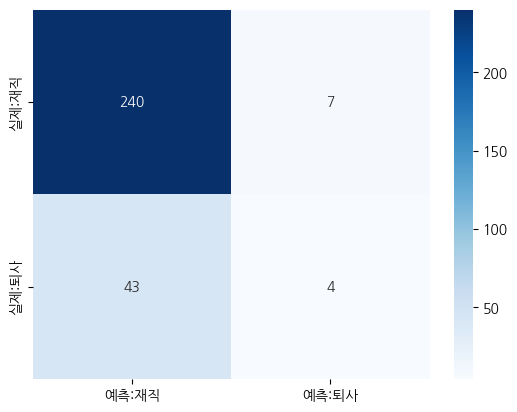

[[240   7]
 [ 43   4]]


In [380]:
# 코드 입력

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

# fmt='d' : 정수형으로 출력
sns.heatmap(data=cm, annot=True, fmt='d', cmap='Blues', xticklabels=['예측:재직', '예측:퇴사'], yticklabels=['실제:재직', '실제:퇴사'])

plt.show()
print(cm)

> 🔮 **예측해보세요**: 히트맵을 확인하기 전에, FN(놓친 퇴사 위험 직원)과 FP(괜한 면담) 중 어느 쪽 숫자가 더 클 것 같은지 먼저 짐작해보세요. 인사팀 입장에서는 어느 쪽이 더 뼈아픈 실수일까요?

### 3) Precision (정밀도) — "퇴사라고 예측한 것 중 진짜 퇴사 비율"

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import precision_score

precision_rf = precision_score(y_test, rf_pred)
print(f"RandomForest Precision: {precision_rf:.3f}")
# 인사팀이 "퇴사 위험군"이라고 면담한 직원 중 실제로 퇴사 위험이 있었던 비율
```

</details>

In [381]:
# 코드 입력

from sklearn.metrics import precision_score

precision_rf = precision_score(y_test, rf_pred)

print(f"RandomForest Precision: {precision_rf:.3f}")
# 인사팀이 "퇴사 위험군"이라고 면담한 직원 중 실제로 퇴사 위험이 있었던 비율
# 즉 퇴사 위험이라고 판단한 100명중 36명만 실제 퇴사


RandomForest Precision: 0.364


### 4) Recall (재현율, 민감도) — "실제 퇴사 직원 중 모델이 맞춘 비율"

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import recall_score

recall_rf = recall_score(y_test, rf_pred)
print(f"RandomForest Recall: {recall_rf:.3f}")
# 실제로 퇴사한 직원 중 모델이 미리 잡아낸(면담 대상에 포함시킨) 비율
```

</details>

In [382]:
# 코드 입력
from sklearn.metrics import recall_score

recall_rf = recall_score(y_test, rf_pred)

print(f"RandomForest Recall: {recall_rf:.3f}")
# 실제로 퇴사한 직원 중 모델이 미리 잡아낸(면담 대상에 포함시킨) 비율
# 즉, 실제로 퇴사한 직원 100명중 단 8명만 미리 찾아냄

RandomForest Recall: 0.085


> 🚀 **실무에서는?** 퇴사 예측처럼 "놓치면 핵심 인재를 영영 잃는" 상황에서는 Recall을 더 중요하게 봅니다. 반대로 "괜히 면담하면 시간과 예산만 낭비되고, 멀쩡히 다니던 직원이 오히려 동요"하는 상황을 더 걱정한다면 Precision을 우선시합니다. 실무에서는 이 둘 중 하나만 고르기보다, 비즈니스 상황에 맞는 균형점을 찾는 것이 핵심입니다.

### 5) F1-score — Precision과 Recall의 조화평균

- 모든 직원을 "퇴사 위험"이라고 예측하면
Recall ↑ (거의 다 찾아냄)
Precision ↓ (거짓 경보가 엄청 많음)

반대로

- 정말 확실한 사람만 "퇴사 위험"이라고 예측하면
Precision ↑ (맞춘 비율 높음)
Recall ↓ (많이 놓침)

- Precision과 Recall은 서로 반대 방향으로 움직이는 경우가 많음.

이런 관계를 트레이드오프 Trade off

- Precision만 보면 "맞춘 사람은 잘 맞췄네."

- Recall만 보면 "실제 퇴사자는 거의 못 찾았네."

처럼 서로 다른 결론이 나올 수 있음

- 그래서 두 지표를 동시에 고려하는 하나의 점수

가 필요했고, 그것이 F1-score

- 조화평균(Harmonic Mean)이란?

- 둘 중 하나라도 낮으면 점수를 크게 깎는 평균 (한쪽만 잘해서는 좋은 모델이라고 볼 수 없기 때문)

- Precision과 Recall이 둘 다 높을 때만 F1-score도 높아짐

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import f1_score

f1_rf = f1_score(y_test, rf_pred)
print(f"RandomForest F1-score: {f1_rf:.3f}")
```

</details>

In [383]:
# 코드 입력

from sklearn.metrics import f1_score
f1_rf = f1_score(y_test, rf_pred)

print(f"RandomForest F1-score: {f1_rf:.3f}")


RandomForest F1-score: 0.138


### 6) `classification_report()` — 모든 지표를 한 번에

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred, target_names=["재직", "퇴사"]))
```

</details>

In [384]:
# 코드 입력

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred, target_names=['재직', '퇴사']))


              precision    recall  f1-score   support

          재직       0.85      0.97      0.91       247
          퇴사       0.36      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.61      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



> Accuracy = 0.83 (전체 294명 중 83%를 맞췄다.)

>  실제 재직자는 247명, 재직이라고 예측한 사람의 85%가 실제 재직, 실제 재직자의 97%를 찾아냄

> 재직 예측 성능은 매우 우수

> 실제 퇴사자는 47명, 퇴사라고 예측한 사람 중 36%만 실제 퇴사, 실제 퇴사자의 9%밖에 찾아내지 못함

>  퇴사 예측 성능은 매우 낮음

> macro avg: 재직과 퇴사를 동일한 비중(50:50)으로 평균

> weighted avg: 각 클래스의 데이터 개수(support)를 반영한 평균


### 7) 여러 모델을 한 번에 비교하기

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

preds = {"Logistic": lr_pred, "Tree": tree_pred, "RF": rf_pred, "XGB": xgb_pred}
rows = []
for name, pred in preds.items():
    rows.append({
        "모델": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })
print(pd.DataFrame(rows))
```

</details>

In [385]:
# 코드 입력

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

preds = {"Logistic": lr_pred, "Tree": tree_pred, "RF": rf_pred, "XGB": xgb_pred}
rows = []
for name, pred in preds.items():
    rows.append({
        "모델": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })
print(pd.DataFrame(rows))


         모델  Accuracy  Precision    Recall        F1
0  Logistic  0.863946   0.818182  0.191489  0.310345
1      Tree  0.809524   0.285714  0.127660  0.176471
2        RF  0.829932   0.363636  0.085106  0.137931
3       XGB  0.860544   0.650000  0.276596  0.388060


> Logistic Regression
Accuracy가 가장 높음(86.4%)
Precision도 매우 높음(81.8%)
하지만 Recall은 19.1%

> 퇴사라고 예측하면 대부분 맞지만, 실제 퇴사자의 약 81%를 놓쳤다.


> XGBoost
Accuracy는 Logistic과 거의 비슷함
Recall이 27.7%로 가장 높음
F1-score도 0.388로 가장 높음

> 실제 퇴사자를 가장 많이 찾아내면서 Precision도 비교적 유지하여, 네 모델 중 가장 균형 잡힌 성능을 보였다.

### 8) 서로 다른 지표 비교 — Accuracy vs Precision/Recall

> 🚀 **실무 시나리오**: 만약 인사팀이 예산 부족으로 "올해는 아무도 퇴사 방지 조치 대상으로 삼지 않겠다(=모두 재직으로 찍겠다)"고 한다면 Accuracy는 어떻게 나올까요?

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import numpy as np
from sklearn.metrics import accuracy_score, recall_score

# 극단적인 예: "모두 재직(0)"이라고만 예측하는 게으른 모델
lazy_pred = np.zeros(len(y_test))
print("게으른 모델 Accuracy:", accuracy_score(y_test, lazy_pred))
print("게으른 모델 Recall:", recall_score(y_test, lazy_pred))
```

</details>

In [386]:
# 코드 입력

import numpy as np
from sklearn.metrics import accuracy_score, recall_score

# 극단적인 예: "모두 재직(0)"이라고만 예측하는 게으른 모델
lazy_pred = np.zeros(len(y_test))

print("게으른 모델 Accuracy:", accuracy_score(y_test, lazy_pred))
print("게으른 모델 Recall:", recall_score(y_test, lazy_pred))


게으른 모델 Accuracy: 0.8401360544217688
게으른 모델 Recall: 0.0


> 💡 Accuracy는 꽤 높게 나오지만, Recall은 0입니다 — 퇴사할 직원을 단 한 명도 찾아내지 못했다는 뜻입니다. 이것이 바로 "정확도 84%"라는 숫자 하나만 보고 모델을 신뢰하면 안 되는 이유입니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ 불균형 데이터에서 Accuracy만 보고 "좋은 모델"이라고 판단하는 경우가 가장 흔한 실수입니다.

> ⚠️ Precision과 Recall을 반대로 기억하는 경우가 많습니다 — Precision은 "예측한 것 중", Recall은 "실제 정답 중"이라는 기준점을 꼭 구분해서 외워야 합니다.

---

## 🚀 실무에서는?

> 🚀 실무의 퇴사 예측 프로젝트에서는 보통 Recall을 우선 기준으로 삼되, Precision이 너무 낮아지지 않는 선(즉 F1-score)에서 임계값(threshold)을 조정합니다. `predict()`의 기본 0.5 기준 대신, `predict_proba()`의 임계값을 0.3처럼 낮춰서 더 많은 위험군을 잡아내는 방식도 자주 사용됩니다.

---

## 🧩 Check Point

**Q1.** "퇴사라고 예측한 직원 중 실제로 퇴사한 비율"을 나타내는 지표는? ① Accuracy ② Precision ③ Recall ④ F1
<details><summary>정답</summary>② Precision</details>

**Q2.** "실제 퇴사 직원 중 모델이 놓치지 않고 잡아낸 비율"을 나타내는 지표는? ① Accuracy ② Precision ③ Recall ④ F1
<details><summary>정답</summary>③ Recall</details>

**Q3.** 암 진단처럼 "놓치면 위험한" 문제와 퇴사 예측처럼 "놓치면 인재를 잃는" 문제의 공통점은 무엇일까요? 두 문제 모두 어떤 지표를 더 중요하게 볼까요?
<details><summary>정답</summary>둘 다 "실제 양성(진짜 위험군)을 놓치는 것"의 대가가 크므로 Recall을 더 중요하게 봅니다.</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. (자습 시간에 진행합니다.)

In [387]:
# TODO 1 (Confusion Matrix): RandomForest 모델의 혼동행렬을 계산하고 히트맵으로 시각화하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()
```

</details>

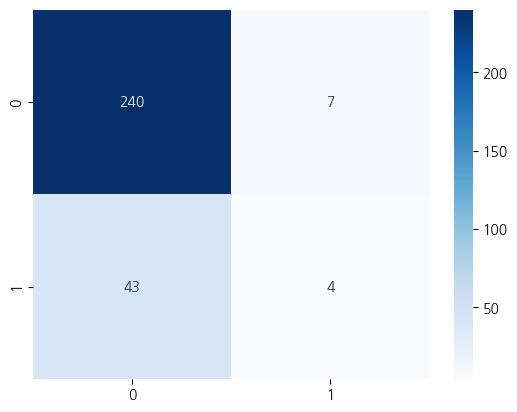

In [388]:
# 코드 입력

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()


In [389]:
# TODO 2 (Precision/Recall/F1): XGBoost 모델의 세 지표를 각각 계산하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1:", f1_score(y_test, xgb_pred))
```

</details>

In [390]:
# 코드 입력

from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1:", f1_score(y_test, xgb_pred))


Precision: 0.65
Recall: 0.2765957446808511
F1: 0.3880597014925373


In [391]:
# TODO 3 (classification_report): DecisionTree 모델의 전체 리포트를 출력하세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import classification_report
print(classification_report(y_test, tree_pred, target_names=["재직", "퇴사"]))
```

</details>

In [392]:
# 코드 입력

from sklearn.metrics import classification_report
print(classification_report(y_test, tree_pred, target_names=["재직", "퇴사"]))


              precision    recall  f1-score   support

          재직       0.85      0.94      0.89       247
          퇴사       0.29      0.13      0.18        47

    accuracy                           0.81       294
   macro avg       0.57      0.53      0.53       294
weighted avg       0.76      0.81      0.78       294



In [393]:
# TODO 4 (종합 비교): 4개 모델의 Accuracy/Precision/Recall/F1을 모두 담은 표를 만드세요


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

preds = {"Logistic": lr_pred, "Tree": tree_pred, "RF": rf_pred, "XGB": xgb_pred}
rows = []
for name, pred in preds.items():
    rows.append({
        "모델": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })
print(pd.DataFrame(rows))
```

</details>

In [394]:
# 코드 입력

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

preds = {"Logistic": lr_pred, "Tree": tree_pred, "RF": rf_pred, "XGB": xgb_pred}
rows = []
for name, pred in preds.items():
    rows.append({
        "모델": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    })
print(pd.DataFrame(rows))


         모델  Accuracy  Precision    Recall        F1
0  Logistic  0.863946   0.818182  0.191489  0.310345
1      Tree  0.809524   0.285714  0.127660  0.176471
2        RF  0.829932   0.363636  0.085106  0.137931
3       XGB  0.860544   0.650000  0.276596  0.388060


---

## 📝 실습 과제

> 📝 자습 시간에 진행합니다.

In [395]:
# 과제 1
# "모두 퇴사(1)"라고만 예측하는 게으른 모델을 만들어 Accuracy와 Precision을 계산하고,
# 왜 이 모델이 실제로는 쓸모없는지 설명해보세요

# 과제 2
# 4개 모델 중 Recall이 가장 높은 모델과 Precision이 가장 높은 모델을 각각 찾아보세요
# (인사팀의 면담·처우 개선 예산이 한정적이라면 어떤 모델을 선택하는 것이 더 안전할지 생각해보기)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import numpy as np
from sklearn.metrics import accuracy_score, precision_score

lazy_pred_all1 = np.ones(len(y_test))
print("Accuracy:", accuracy_score(y_test, lazy_pred_all1))
print("Precision:", precision_score(y_test, lazy_pred_all1))
# 모든 직원을 면담하는 셈이라 Recall은 1이 되지만, 실제로는 시간·예산 낭비가 심각함
```

</details>

In [396]:
# 과제 1 답안

import numpy as np
from sklearn.metrics import accuracy_score, precision_score

lazy_pred_all1 = np.ones(len(y_test))
print("Accuracy:", accuracy_score(y_test, lazy_pred_all1))
print("Precision:", precision_score(y_test, lazy_pred_all1))
# 모든 직원을 면담하는 셈이라 Recall은 1이 되지만, 실제로는 시간·예산 낭비가 심각함


Accuracy: 0.1598639455782313
Precision: 0.1598639455782313


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.metrics import recall_score, precision_score

preds = {"Logistic": lr_pred, "Tree": tree_pred, "RF": rf_pred, "XGB": xgb_pred}
for name, pred in preds.items():
    print(name, "Recall:", round(recall_score(y_test, pred), 3),
          "Precision:", round(precision_score(y_test, pred), 3))
# 면담 예산이 한정적이라면(괜한 면담 최소화) Precision이 높은 모델을,
# 퇴사 위험 직원을 최대한 놓치지 않는 게 우선이라면 Recall이 높은 모델을 선택
```

</details>

In [397]:
# 과제 2 답안

from sklearn.metrics import recall_score, precision_score

preds = {"Logistic": lr_pred, "Tree": tree_pred, "RF": rf_pred, "XGB": xgb_pred}
for name, pred in preds.items():
    print(name, "Recall:", round(recall_score(y_test, pred), 3),
          "Precision:", round(precision_score(y_test, pred), 3))
# 면담 예산이 한정적이라면(괜한 면담 최소화) Precision이 높은 모델을,
# 퇴사 위험 직원을 최대한 놓치지 않는 게 우선이라면 Recall이 높은 모델을 선택


Logistic Recall: 0.191 Precision: 0.818
Tree Recall: 0.128 Precision: 0.286
RF Recall: 0.085 Precision: 0.364
XGB Recall: 0.277 Precision: 0.65


---

## 📌 핵심 정리

- Confusion Matrix: TP/TN/FP/FN으로 어떤 실수를 했는지 자세히 확인
- Precision: 퇴사라고 예측한 것 중 진짜 퇴사 비율
- Recall: 실제 퇴사 직원 중 모델이 놓치지 않고 잡아낸 비율
- F1: Precision과 Recall의 균형
- 불균형 데이터에서는 Accuracy만으로 모델을 판단하면 위험함

# 🎁 CH12-B (보너스). 내 조건으로 집값 예측기 — LightGBM 참전

━━━━━━━━━━━━━━━━

> 🗂️ **챕터 구성**: 데이터 준비(아파트 실거래) → XGBoost 학습 → LightGBM 참전·비교 → 내 조건으로 예측
> 🔧 **실습파일**: 필요 (`apt_price_2026.csv` — 사전 배포)
> ⏱️ **예상 소요시간**: 20~30분
> 🎚️ **난이도**: ★★★☆☆
> 🔗 **사전 지식**: CH03-02-01, CH03-02-02
> ⏭️ 이 소단원은 진도 상황에 따라 건너뛸 수 있는 보너스이며, 정규 4시간 개념 진도에 포함되지 않습니다.

---

## 🤔 먼저 생각해보기

> **오늘 하루 종일 배운 회귀 모델로, 이번엔 여러분이 가장 궁금해할 숫자를 예측해봅니다 — "내가 원하는 조건의 아파트, 얼마일까?" 프롭테크 기업의 데이터 분석가가 되어 실거래 데이터로 가격 예측 모델을 만들고, 각자 원하는 조건을 직접 넣어 예측해봅니다.**

여기에 오늘 배운 XGBoost의 라이벌이자 Kaggle 대회 상위권의 단골손님인 **LightGBM**도 참전시켜 성능을 겨뤄봅니다.

> 💡 실습 데이터(`apt_price_2026.csv`)는 국토교통부 실거래가 공개시스템의 데이터 형식을 본떠 교육용으로 구성한 가상 도시의 아파트 거래 데이터(4,800건)입니다. 구(區), 전용면적, 층, 건축년도, 지하철역 거리, 브랜드 등급 등 실제 집값을 결정하는 요인들이 그대로 반영되어 있습니다.

### 0) 데이터 준비 — 아파트 실거래 데이터

- `구`(지역), `전용면적_m2`, `층`, `건축년도`, `지하철역_거리_m`, `방개수`, `욕실개수`, `브랜드등급`(1~3) 등 8개 특성
- 목표값(`거래금액_만원`): 실제 거래된 가격 (연속적인 숫자 → 회귀 문제)
- 파일은 노트북과 같은 폴더에 두고 실행하세요 (Colab이라면 왼쪽 파일 탭에 업로드)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd
from sklearn.model_selection import train_test_split

df_apt = pd.read_csv("apt_price_2026.csv")
print(df_apt.shape)
print(df_apt.head())
print("가격 분포(억 단위):")
print((df_apt["거래금액_만원"] / 10000).describe().round(2))
```

</details>

In [398]:
# 코드 입력

import pandas as pd
from sklearn.model_selection import train_test_split

df_apt = pd.read_csv("apt_price_2026.csv")
print(df_apt.shape)
display(df_apt.head())

print("가격 분포(억 단위):")
print((df_apt["거래금액_만원"] / 10000).describe().round(2))


(4800, 9)


,구,전용면적_m2,층,건축년도,지하철역_거리_m,방개수,욕실개수,브랜드등급,거래금액_만원
0,구도심구,74.13,6,1996,504,3,1,2,50900
1,신도심구,60.08,9,2009,641,3,1,2,76100
2,호수구,49.86,27,1994,460,2,1,3,54100
3,구도심구,84.32,27,2012,2098,3,1,3,73300
4,중앙구,100.17,4,2011,820,4,2,1,173300


가격 분포(억 단위):
count    4800.00
mean       10.52
std         4.18
min         2.94
25%         7.37
50%         9.74
75%        12.88
max        30.51
Name: 거래금액_만원, dtype: float64


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 오전에 배운 흐름 그대로: 인코딩 → 분할
X = pd.get_dummies(df_apt.drop(columns=["거래금액_만원"]), columns=["구"], drop_first=True)
y = df_apt["거래금액_만원"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
```

</details>

In [399]:
# 오전에 배운 흐름 그대로: 인코딩 → 분할

# Step1. One-hot Encoding
import pandas as pd
df_enc = pd.get_dummies(df_apt, columns=['구'], drop_first=True)

# Step2. 입력 변수(X)와 목표 변수(y) 분리
X = df_enc.drop(columns=['거래금액_만원'])
y = df_enc['거래금액_만원']

# Step3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)


(3840, 11) (960, 11)


### 1) XGBoost로 가격 예측 모델 만들기 (오늘 배운 그대로)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

xgb_apt = XGBRegressor(n_estimators=200, random_state=42)
xgb_apt.fit(X_train, y_train)

xgb_pred = xgb_apt.predict(X_test)
print("XGBoost RMSE(만원):", round(root_mean_squared_error(y_test, xgb_pred)))
print("XGBoost R2:", round(r2_score(y_test, xgb_pred), 3))
```

</details>

In [400]:
# 코드 입력

from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# 모델 학습
xgb_apt = XGBRegressor(n_estimators=200, random_state=42)
xgb_apt.fit(X_train, y_train)

# 예측
xgb_pred = xgb_apt.predict(X_test)

print("XGBoost RMSE(만원):", round(root_mean_squared_error(y_test, xgb_pred)))
print("XGBoost R2:", round(r2_score(y_test, xgb_pred), 3))


XGBoost RMSE(만원): 9823
XGBoost R2: 0.946


### 2) LightGBM 참전 — XGBoost의 라이벌

- Microsoft가 만든 그래디언트 부스팅 라이브러리로, XGBoost보다 **학습 속도가 빠르고** 대용량 데이터에 강한 것이 특징
- Kaggle 등 데이터 분석 대회에서 XGBoost와 함께 우승을 양분하는 실무 표준 모델
- 사용법은 XGBoost와 거의 동일 — 오늘 배운 `fit()` → `predict()` 흐름이 그대로 통합니다

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 사전 설치 필요: pip install lightgbm
from lightgbm import LGBMRegressor

lgbm_apt = LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
lgbm_apt.fit(X_train, y_train)

lgbm_pred = lgbm_apt.predict(X_test)
print("LightGBM RMSE(만원):", round(root_mean_squared_error(y_test, lgbm_pred)))
print("LightGBM R2:", round(r2_score(y_test, lgbm_pred), 3))
```

</details>

In [401]:
# 사전 설치 필요: pip install lightgbm
from lightgbm import LGBMRegressor

# 모델 학습
lgbm_apt = LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
lgbm_apt.fit(X_train, y_train)

# 예측
lgbm_pred = lgbm_apt.predict(X_test)
print("LightGBM RMSE(만원):", round(root_mean_squared_error(y_test, lgbm_pred)))
print("LightGBM R2:", round(r2_score(y_test, lgbm_pred), 3))


LightGBM RMSE(만원): 8746
LightGBM R2: 0.957


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 두 모델 성능을 한 표로 비교 (CH03-02-02에서 배운 지표 활용)
compare = pd.DataFrame({
    "모델": ["XGBoost", "LightGBM"],
    "RMSE(만원)": [round(root_mean_squared_error(y_test, xgb_pred)),
                  round(root_mean_squared_error(y_test, lgbm_pred))],
    "R2": [round(r2_score(y_test, xgb_pred), 3), round(r2_score(y_test, lgbm_pred), 3)],
})
print(compare)
```

</details>

In [402]:
# 두 모델 성능을 한 표로 비교 (CH03-02-02에서 배운 지표 활용)
compare = pd.DataFrame({
    "모델": ["XGBoost", "LightGBM"],
    "RMSE(만원)": [round(root_mean_squared_error(y_test, xgb_pred)),
                  round(root_mean_squared_error(y_test, lgbm_pred))],
    "R2": [round(r2_score(y_test, xgb_pred), 3), round(r2_score(y_test, lgbm_pred), 3)],
})
print(compare)


         모델  RMSE(만원)     R2
0   XGBoost      9823  0.946
1  LightGBM      8746  0.957


> 🚀 **실무에서는?** 프롭테크 기업들의 아파트 시세 추정 서비스도 원리는 오늘 여러분이 만든 것과 같습니다 — 실거래 데이터로 회귀 모델을 학습시키고, 조건을 넣어 가격을 추정합니다. 실제 서비스는 여기에 학군, 조망, 매물 호가, 시장 심리 같은 특성을 수백 개 더 넣어 정교하게 만든 버전입니다.

### 3) 내 조건으로 예측하기 — 오늘의 하이라이트

> ✏️ **직접 해보기**: 아래 `my_home` 딕셔너리의 값을 여러분이 원하는 조건으로 자유롭게 바꿔서 다시 실행해보세요. "신축 vs 구축", "역세권 vs 비역세권", "저층 vs 로열층"의 가격 차이를 모델이 어떻게 추정하는지 직접 확인할 수 있습니다.

In [403]:
# 참고
# 평 → 제곱미터(㎡) 계산기

py = float(input("평수를 입력하세요: "))

sqm = py * 3.3058 * 0.75

print(f"{py}평 = {sqm:.2f}㎡")

평수를 입력하세요: 30
30.0평 = 74.38㎡


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 내가 원하는 아파트 조건을 딕셔너리로 입력
my_home = {
    "전용면적_m2": 84,        # 국민평형 (34평형)
    "층": 12,
    "건축년도": 2018,
    "지하철역_거리_m": 350,    # 역세권
    "방개수": 3,
    "욕실개수": 2,
    "브랜드등급": 2,           # 1=일반, 2=중견, 3=대형 브랜드
    "구": "신도심구",          # 중앙구 / 강변구 / 신도심구 / 구도심구 / 호수구
}

# 학습 데이터와 동일한 형태로 인코딩 (없는 구 컬럼은 0으로 채움)
my_df = pd.get_dummies(pd.DataFrame([my_home]), columns=["구"])
my_df = my_df.reindex(columns=X.columns, fill_value=0)

price = lgbm_apt.predict(my_df)[0]
print(f"이 조건의 예측 가격: 약 {price / 10000:.1f}억 원")
```

</details>

In [404]:
# 내가 원하는 아파트 조건을 딕셔너리로 입력
my_home = {
    "전용면적_m2": 84,        # 국민평형 (34평형)
    "층": 12,
    "건축년도": 2018,
    "지하철역_거리_m": 350,    # 역세권
    "방개수": 3,
    "욕실개수": 2,
    "브랜드등급": 2,           # 1=일반, 2=중견, 3=대형 브랜드
    "구": "신도심구",          # 중앙구 / 강변구 / 신도심구 / 구도심구 / 호수구
}

# 학습 데이터와 동일한 형태로 인코딩 (없는 구 컬럼은 0으로 채움)
my_df = pd.get_dummies(pd.DataFrame([my_home]), columns=["구"])
my_df = my_df.reindex(columns=X.columns, fill_value=0)

price = lgbm_apt.predict(my_df)[0]
print(f"이 조건의 예측 가격: 약 {price / 10000:.1f}억 원")


이 조건의 예측 가격: 약 13.0억 원


In [405]:
# 코드 입력

# ✏️ 여기에 나만의 조건으로 바꿔서 예측해보세요
my_home = {
    "전용면적_m2": 120,
    "층": 12,
    "건축년도": 2025,
    "지하철역_거리_m": 300,    # 역세권
    "방개수": 2,
    "욕실개수": 1,
    "브랜드등급": 3,           # 1=일반, 2=중견, 3=대형 브랜드
    "구": "신도심구",          # 중앙구 / 강변구 / 신도심구 / 구도심구 / 호수구
}

# 학습 데이터와 동일한 형태로 인코딩 (없는 구 컬럼은 0으로 채움)
my_df = pd.get_dummies(pd.DataFrame([my_home]), columns=["구"])
my_df = my_df.reindex(columns=X.columns, fill_value=0)

price = lgbm_apt.predict(my_df)[0]
print(f"이 조건의 예측 가격: 약 {price / 10000:.1f}억 원")


이 조건의 예측 가격: 약 18.6억 원


---

## 📝 실습 과제 (선택)

> 📝 자습 시간에 여유가 있다면 도전해보세요.

In [406]:
# 과제 1
# 같은 조건에서 "구"만 5개 지역으로 각각 바꿔가며 예측 가격을 비교해보세요 (지역 프리미엄 체감)

# 과제 2
# LightGBM 모델의 특성 중요도(feature_importances_)를 확인하고,
# 집값에 가장 큰 영향을 주는 요인이 무엇인지 찾아보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
for gu in ["중앙구", "강변구", "신도심구", "구도심구", "호수구"]:
    cond = dict(my_home)
    cond["구"] = gu
    cond_df = pd.get_dummies(pd.DataFrame([cond]), columns=["구"]).reindex(columns=X.columns, fill_value=0)
    print(gu, f"{lgbm_apt.predict(cond_df)[0] / 10000:.1f}억")
```

</details>

In [407]:
# 과제 1 예시 정답

for gu in ["중앙구", "강변구", "신도심구", "구도심구", "호수구"]:
    cond = dict(my_home)
    cond["구"] = gu
    cond_df = pd.get_dummies(pd.DataFrame([cond]), columns=["구"]).reindex(columns=X.columns, fill_value=0)
    print(gu, f"{lgbm_apt.predict(cond_df)[0] / 10000:.1f}억")



중앙구 26.4억
강변구 21.4억
신도심구 18.6억
구도심구 12.7억
호수구 14.9억


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
importance = pd.Series(lgbm_apt.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(5))
```

</details>

In [408]:
# 과제 2 예시 정답

importance = pd.Series(lgbm_apt.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(5))


전용면적_m2      1741
지하철역_거리_m    1466
건축년도         1096
층             867
브랜드등급         243
dtype: int32


In [409]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## 📌 핵심 정리

- 오늘 배운 회귀 파이프라인(인코딩 → 분할 → fit → predict → RMSE/R2)은 데이터가 바뀌어도 그대로 재사용됨
- LightGBM: XGBoost의 라이벌, 더 빠른 학습 속도, 사용법은 거의 동일
- 학습에 쓴 특성 구조와 동일한 형태로 만들어야 새 데이터 예측 가능 (`reindex(columns=X.columns)`)
- 실무의 시세 추정 서비스도 본질은 "실거래 데이터 + 회귀 모델"의 확장판

## 🎉 수업 완료!